# 1D-Project

# 1: ECG & Respiration
In this exercise, we try to study the connection between breathing and the ECG amplitude. We analyze an ECG signal (as a biomarker for the heart activity) and a nasal flow signal (which measures breathing using temperature changes during exhalation). By comparing these, we can see how breathing affects the heart's activity.

## 1-1: ECG RR Intervals

The goal is to detect and analyze R peaks in ECG signals to calculate R-R intervals and amplitudes, introducing basic ECG signal processing.
Tasks:
- Identify R peaks using scipy.signal.find_peaks.
- calculate R-R intervals and amplitudes of R peaks.

The data is from the https://www.physionet.org/content/challenge-2000/1.0.0/ study on detecting & quantifying apnea. 
We use the following columns:
- ECG
- Resp N: oronasal airflow measured using nasal thermistors

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks, decimate

In the first step, we load the signal from the file. We set the sampling rate to 100 Hz and load it from the CSV. We know from looking at the CSV that the ECG is the second and the respiration the 5th column. We store this in the variable y. 
Then we set the first column of y (the ECG) to y_ecg and the second column to y_resp.

We use len(y) to find out the length of y = the number of samples we have available and set it to K (for the indices).
Then we plot the ecg signal vs. the number of samples. 

### Import & Plot for Overview

Filename: 1D Exercises/apnea-ecg-a01er-data.csv
Number of loaded samples:  6000
Total signal duration [s]:  60.0
Signal shape and samples (6000,) : [[-0.06   0.235]
 [-0.065  0.236]
 [-0.06   0.237]
 ...
 [ 0.04  -0.112]
 [ 0.07  -0.113]
 [ 0.09  -0.115]]


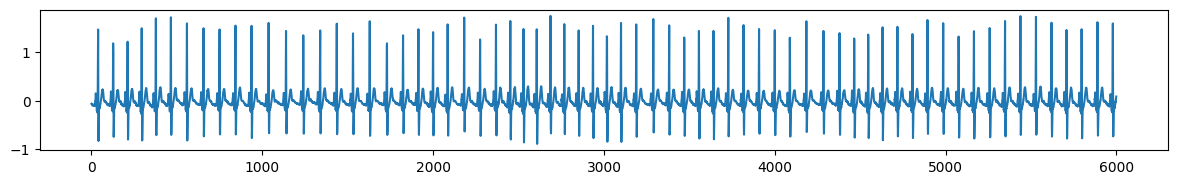

In [3]:
file_name = '1D Exercises/apnea-ecg-a01er-data.csv'
fs = 100  # sampling rate [Hz] of recorded signal
# -- LOAD TEST SIGNAL --
y = np.genfromtxt(file_name, usecols=(1,4), delimiter=r',', skip_header=1, )
y_ecg = y[:,0] # first column is ECG signal
y_resp = y[:,1] # second column is respiration signal
K = len(y)
k = np.arange(K) #creating array of integers from 0 to K-1 -> indices of samples


# plot signal
fig, axs = plt.subplots(1, 1, sharex='all', figsize=(12, 2))
fig.tight_layout()
axs.plot(k, y_ecg)

print("Filename:", file_name)
print("Number of loaded samples: ",K)
print("Total signal duration [s]: ", K/fs)
print("Signal shape and samples "+str(y_ecg.shape)+" : "+str(y))

### a) Find R Waves
To find the R wave (the positive peak of the QRS comples), we use find_peaks() from scipy.signal. 

I set a distance, because it detected 1044 peaks, which is not what we want to achieve. With "normal" physiological heart rates of ca. 60-80 bpm and a sample of 1minute, we expect something more or less in this range. I adjusted the distance until I got an appropriate number of peaks. The distance measures the required minimal horizontal distance (>= 1) in samples between neighbouring peaks.


**Calculate a good distance**:
We can calculate Minimum Distance (samples)= Sampling Rate (Hz) / Maximum Expected Heart Rate (Hz).
So in our case, this could be 

100 / (80/60) (divide by 60 to convert bpm to Hz (= per second), because this is SI unit)

This gives me a distance of 75, with which I achieve the 67 peaks. 

In [91]:
y_peaks = find_peaks(y_ecg, height=None, distance=75)
nof_peaks = len(y_peaks[0])


print("Indices of minima: ", y_peaks[0])
print("Total number of peaks found: ",nof_peaks)
if nof_peaks == 0:
    print("No maxima found. Exit.")
    exit()

Indices of minima:  [  39  127  212  294  377  465  559  656  750  843  937 1037 1139 1240
 1339 1436 1531 1629 1730 1824 1914 2000 2085 2182 2275 2368 2452 2529
 2607 2687 2768 2852 2936 3017 3100 3189 3289 3382 3470 3556 3641 3728
 3817 3908 4000 4088 4185 4285 4379 4465 4547 4631 4718 4806 4894 4986
 5076 5166 5258 5348 5438 5529 5620 5708 5796 5889 5979]
Total number of peaks found:  67


### b) Calculate R-R intervals
Now I compute the R-R intervals between the peaks detected in the previous exercise. 
I look at the intervals in terms of samples between the peaks, secons between the peaks, and amplitudes of the R peaks.

1. R-R intervals in samples: calculated by difference between peak indices from 1-1a -> necessary for calculating 2 
2. R-R in seconds: we divide R-R in samples by the sampling frequenzy (100Hz) to get the amount of time passed between each peak (in seconds -> SI units)
3. Amplitude: computed through value of the signal (y_ecg) at the index (y_peaks[0])


In [92]:
# 1. R-R intervals in samples
rr_intervals = np.diff(y_peaks[0])

# 2. R-R intervals in seconds
rr_intervals_time = rr_intervals / fs  # by dividing by sampling rate, we get the time

# 3. R peak amplitudes
r_peak_amplitudes = y_ecg[y_peaks[0]] #amplitude of y at the indices of peaks


# Print results
print("R-R Intervals (in samples):", rr_intervals)
print("R-R Intervals (in seconds):", rr_intervals_time)
print("R Peak Amplitudes:", r_peak_amplitudes)


R-R Intervals (in samples): [ 88  85  82  83  88  94  97  94  93  94 100 102 101  99  97  95  98 101
  94  90  86  85  97  93  93  84  77  78  80  81  84  84  81  83  89 100
  93  88  86  85  87  89  91  92  88  97 100  94  86  82  84  87  88  88
  92  90  90  92  90  90  91  91  88  88  93  90]
R-R Intervals (in seconds): [0.88 0.85 0.82 0.83 0.88 0.94 0.97 0.94 0.93 0.94 1.   1.02 1.01 0.99
 0.97 0.95 0.98 1.01 0.94 0.9  0.86 0.85 0.97 0.93 0.93 0.84 0.77 0.78
 0.8  0.81 0.84 0.84 0.81 0.83 0.89 1.   0.93 0.88 0.86 0.85 0.87 0.89
 0.91 0.92 0.88 0.97 1.   0.94 0.86 0.82 0.84 0.87 0.88 0.88 0.92 0.9
 0.9  0.92 0.9  0.9  0.91 0.91 0.88 0.88 0.93 0.9 ]
R Peak Amplitudes: [1.47  1.185 1.22  1.495 1.7   1.72  1.595 1.495 1.47  1.55  1.545 1.605
 1.44  1.35  1.45  1.59  1.39  1.64  1.185 1.35  1.475 1.415 1.575 1.715
 1.265 1.57  1.645 1.48  1.475 1.75  1.58  1.45  1.545 1.33  1.605 1.575
 1.685 1.555 1.305 1.44  1.44  1.71  1.56  1.48  1.455 1.3   1.64  1.44
 1.395 1.285 1.365 1.515 1.525

#### Plotting the Peaks

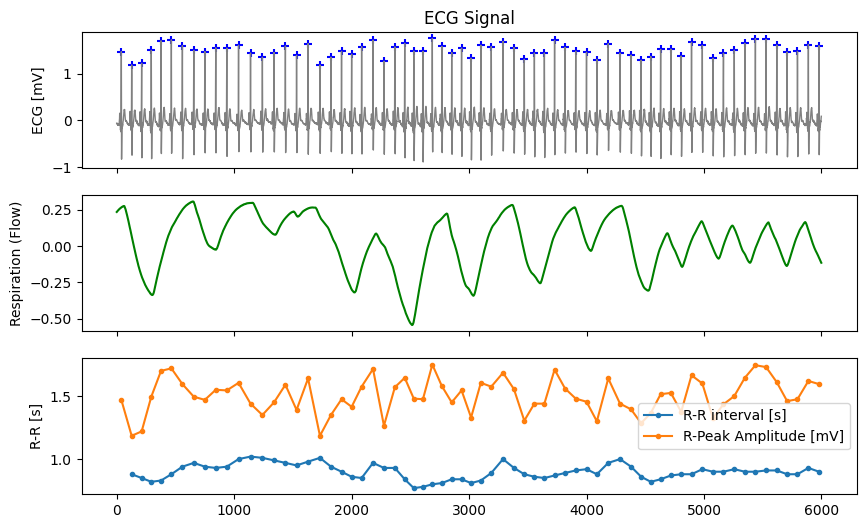

In [93]:
fig, axs = plt.subplots(3, 1, sharex='all', figsize=(10, 6))
axs[0].plot(k, y_ecg, lw=1.0, color='gray')
axs[0].scatter(y_peaks[0], y_ecg[y_peaks[0]], c='b', marker='+')
axs[0].set_title("ECG Signal")
axs[0].set_ylabel('ECG [mV]')

axs[1].plot(k, y_resp, 'g-', label='Respiration')
axs[1].set_ylabel('Respiration (Flow)')

axs[2].plot(y_peaks[0][1:], rr_intervals_time, '.-', label='R-R interval [s]')
axs[2].plot(y_peaks[0], r_peak_amplitudes, '.-', label='R-Peak Amplitude [mV]')
axs[2].set_ylabel('R-R [s]')
axs[2].legend()

plt.show()

## 1-2 ECG vs. Breathing
This exercise is to check whether we can observe the offect of the correlation between breathing activity and the ECG changes (R-R Intervals & QRS peak amplitudes).

1) scatter plots: R-R interval vs. Respiration & R peak amplitude vs. Respiration
2) add linear regression line
3) correlation coefficients

### Sample Respiration Values at Peaks
In the first step, I need to sample the respiration values at the peaks for the scatter plot.

In [94]:
respiration_values = [y_resp[idx] for idx in y_peaks[0]]

### Linear Regression
Fitting the regression line (y = mx +b) for the two plots.

In [95]:
from scipy.stats import linregress

# Linear regression of R-R intervals vs. respiration signal
slope_rr, intercept_rr, r_value_rr, _, _ = linregress(respiration_values[1:], rr_intervals_time)
regression_line_rr = [slope_rr * x + intercept_rr for x in respiration_values]

# Linear regression of R peak amplitudes vs. respiration signal
slope_amp, intercept_amp, r_value_amp, _, _ = linregress(respiration_values, r_peak_amplitudes)
regression_line_amp = [slope_amp * x + intercept_amp for x in respiration_values]


#### Plot 1: R-R Interval vs. Respiration
This graph plots the R-R Interval vs. the Respiration. The regression coefficient of the regression line is 0.71, which indicates a moderate to strong positive linear correlation.

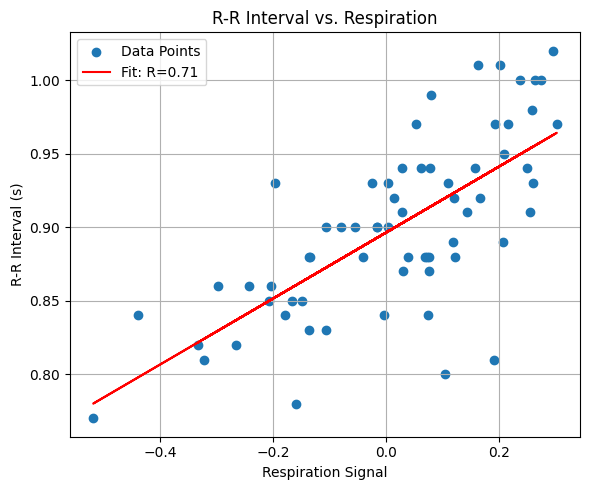

In [96]:
# Plot 1: R-R Interval vs. Respiration
plt.figure(figsize=(6, 5))
plt.scatter(respiration_values[1:], rr_intervals_time, label="Data Points")
plt.plot(respiration_values, regression_line_rr, color="red", label=f"Fit: R={r_value_rr:.2f}")
plt.xlabel("Respiration Signal")
plt.ylabel("R-R Interval (s)")
plt.title("R-R Interval vs. Respiration")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


#### Plot 2: R Peak Amplitude vs. Respiration
This graph plots the R-R Interval vs. the Respiration. The regression coefficient of the regression line is 0.18, which indicates a very weak positive linear correlation.

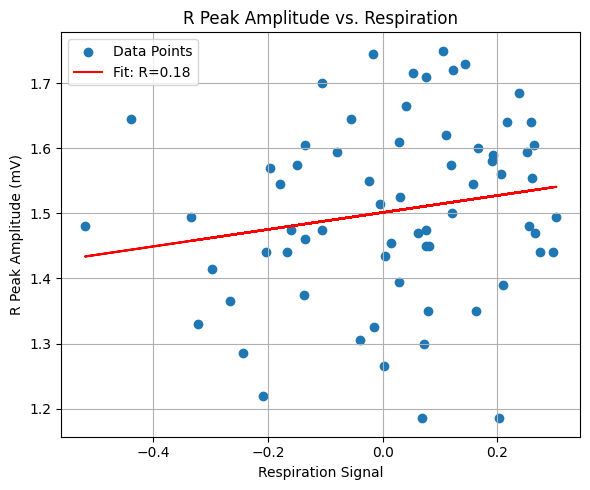

In [97]:
plt.figure(figsize=(6, 5))
plt.scatter(respiration_values, r_peak_amplitudes, label="Data Points")
plt.plot(respiration_values, regression_line_amp, color="red", label=f"Fit: R={r_value_amp:.2f}")
plt.xlabel("Respiration Signal")
plt.ylabel("R Peak Amplitude (mV)")
plt.title("R Peak Amplitude vs. Respiration")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Scientific Backing: 
This finding aligns with the principle of respiratory sinus arrhythmia. 
This is a physiological phenomenon where the R-R interval is shortened during inspiration and prolonged during expiration.

# 2: FIR: MA Filters on ECGs
The goal of this exercise is to apply and analyze the effect of moving average (MA) filters on ECG signals using Python. 

**FIR**: Only depends on current and past input values, no feedback (non-recursive).


## Importing Signal
We import the signal from the csv. (Or use the synthetic test signal provided)

In [137]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter

import lmlib as lm
from lmlib.utils.generator import load_lib_csv, gen_rect


# --------------- loading test signal -----------------------
# Choose between real and synthetic test signal by setting one of them to "True".
if True: # Real ECG Signal
    file_name = 'SECG3_FILT_HP51_3CH_20S_FS2400HZ.csv'
    fs = 2400  # sampling rate [Hz] of recorded signal
    K = fs*3  # number of samples to process. Here: fs*<number of seconds>
    x = load_lib_csv(file_name, K, k_start=40000, channel=1)

if False: # Syntetic Test signal
    file_name = '(Synthetic Rectangle at 0.5Hz)'
    fs = 1000  # sampling rate [Hz] of recorded signal
    f = 2 # [Hz] Frequency of rectangular singnal
    K = fs*3  # number of samples to process. Here: fs*<number of seconds>
    x = gen_rect(K, fs//f)

    
k = np.arange(K) # create time index vector
        

## Plotting the Signal

Filename: SECG3_FILT_HP51_3CH_20S_FS2400HZ.csv
Number of loaded samples:  7200
Total signal duration [s]:  3.0
Signal shape and samples (7200,) : [-0.10159042 -0.09090671 -0.09311861 ... -0.00629024 -0.01344763
 -0.01657154]


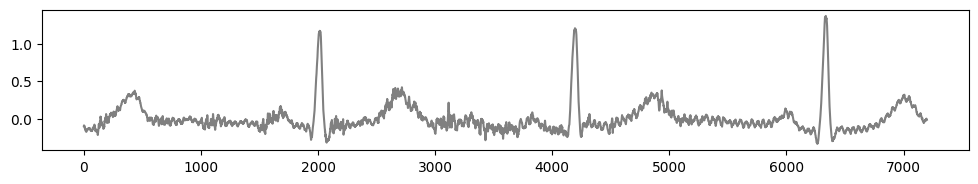

In [138]:
fig, axs = plt.subplots(1, 1, sharex='all', figsize=(10, 2))
fig.tight_layout()
axs.plot(k, x, color='gray')

print("Filename:", file_name)
print("Number of loaded samples: ",K)
print("Total signal duration [s]: ", K/fs)
print("Signal shape and samples "+str(x.shape)+" : "+str(x))

It is visible, that this signal is a bit noisy and has some small oscillations / irregularities which could be due to noise.

## 2-1 Applying the Moving Average Filter


We have the following instructions:
1. Modify h 
2. Tune L -> so that noise components in ECG get surpressed but ECG is not altered too much
3. Optimize Signal-to-Noise (SNR) ratio.

### Signal-to-Noise Ratio (SNR)
SNR is a measure of how much of strong a signal in a sample is in relation to the noise. The result is a ratio in decibels (dB).

- High SNR = signal is strong compared to noise -> good quality
- low SNR = noise is significant relative to the signal 

-> **we want to make our SNR higher with the Moving Average Filter**

#### Calculation
It is calculated like this:

![SNR](SNR.png)


##### Signal Power
Signal Power measures the strength or energy of the signal in the sample -> how useful is the information of the signal in the sample?

Calculation: average of the squared values of the filtered signal
= **mean squared value**

##### Noise Power
average energy of the noise (undesired differences)

Calculation: mean of the squared differences between the original and filtered signals

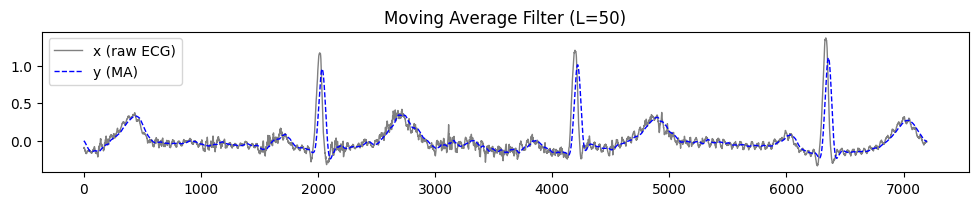

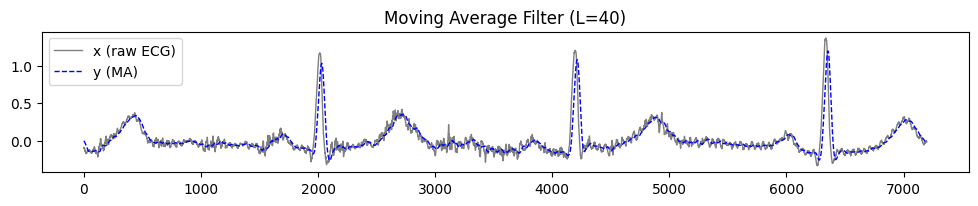

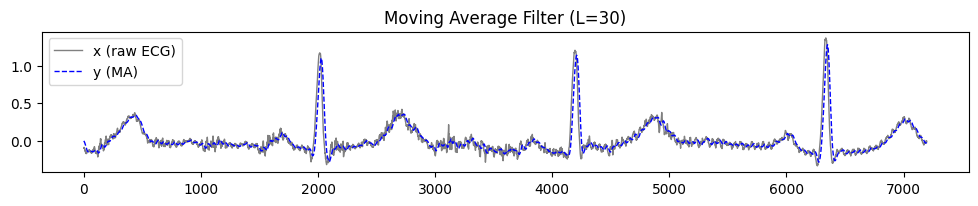

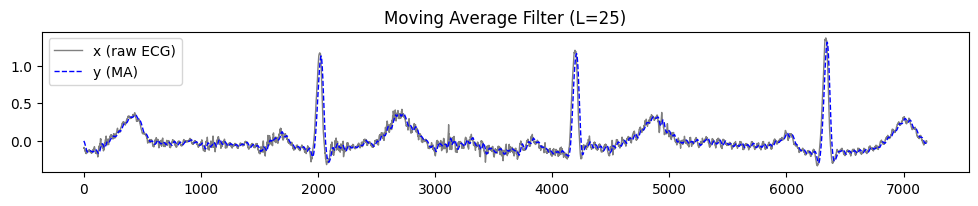

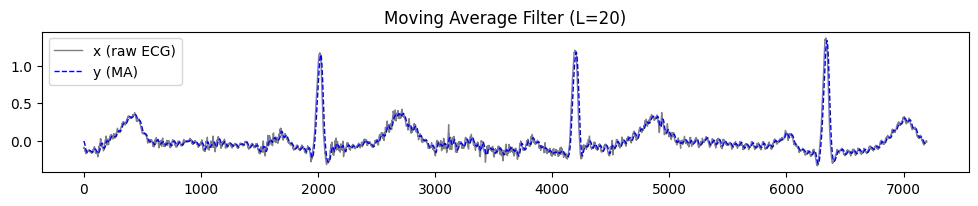

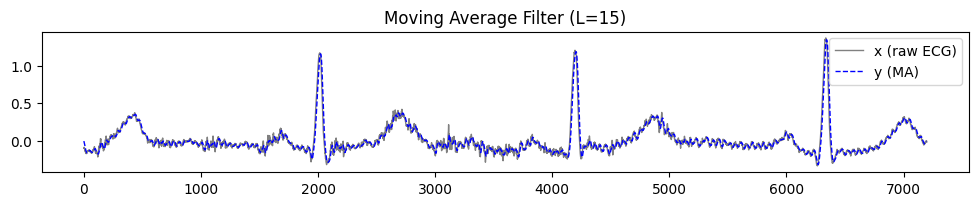

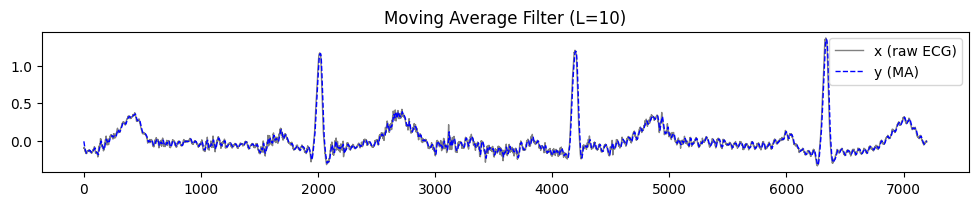

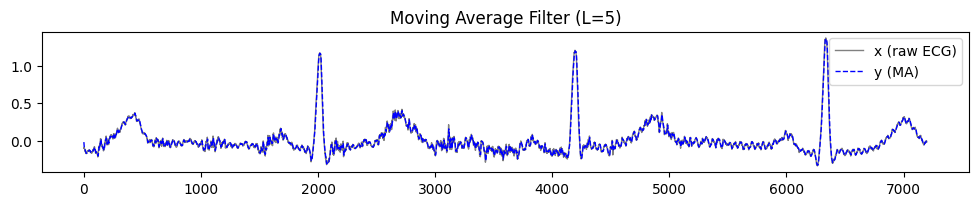

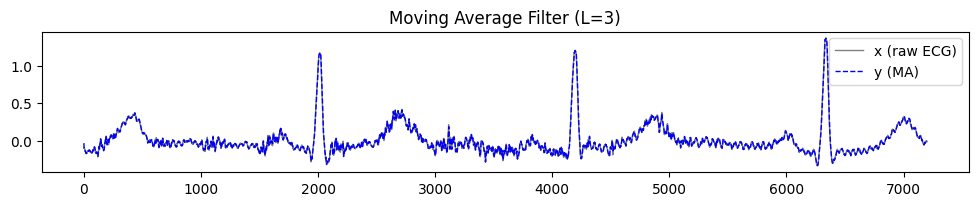

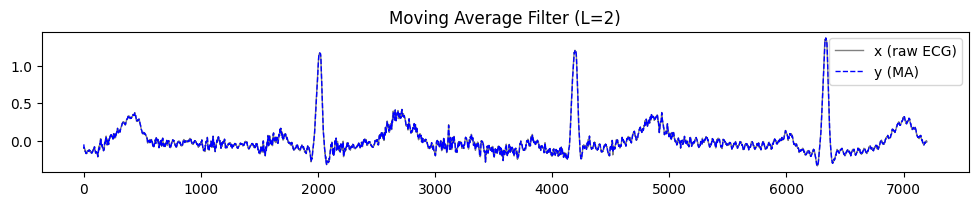

L = 50, Output SNR = 2.35 dB
L = 40, Output SNR = 3.87 dB
L = 30, Output SNR = 5.92 dB
L = 25, Output SNR = 7.27 dB
L = 20, Output SNR = 8.95 dB
L = 15, Output SNR = 11.12 dB
L = 10, Output SNR = 14.14 dB
L = 5, Output SNR = 19.41 dB
L = 3, Output SNR = 24.03 dB
L = 2, Output SNR = 29.04 dB


In [100]:
L_values = [50, 40, 30, 25, 20, 15, 10, 5, 3, 2]

snr_list = []
for L in L_values: #iterating over possible window sizes
    h = np.ones(L) / L  
    filtered_signal = lfilter(h, 1, x) # applying moving average filter
    signal_power = np.mean(filtered_signal**2)
    noise_power = np.mean((x - filtered_signal)**2)
    snr =  10 * np.log10(signal_power / noise_power) # calculate SNR in dB
    snr_list.append((L, snr))
    
    #Plotting filter results
    fig, axs = plt.subplots(1, 1, sharex='all', figsize=(10, 2))
    fig.tight_layout()
    axs.plot(k, x, lw=1.0, color='gray', label="x (raw ECG)")
    axs.plot(k, filtered_signal, lw=1.0, ls='--', color='blue', label="y (MA)")
    axs.set_title("Moving Average Filter (L="+str(L)+")")

    axs.legend()

    plt.show()

# Display the results
for L, snr_out in snr_list:
    print(f"L = {L}, Output SNR = {snr_out:.2f} dB")

**How to choose the best L?**

It is a trade-off between noise reduction and preserving important signal features like the QRS complex we want to examine. 
- If we choose a high L, we might over-smooth and lose information, causing the SNR to drop (because the signal power gets lower.)
- If we choose a low L, the reduction in noise might not be so great, but we are less likely to lose relevant information.

I decided for L = 25 because it is somewhere in the middle, achieves a good SNR but doesn't smooth out too much.


### Applying a Causal Moving Average Filter
= causal because I am using lfilter
- Alternative: could also apply the filtfilt which applies the filter forwards and backwards 
  - this would be a non-causal filter, because it uses values not only from past and present, but also from the future -> would not be suitable for real-time filtering

Output SNR = 7.27 dB


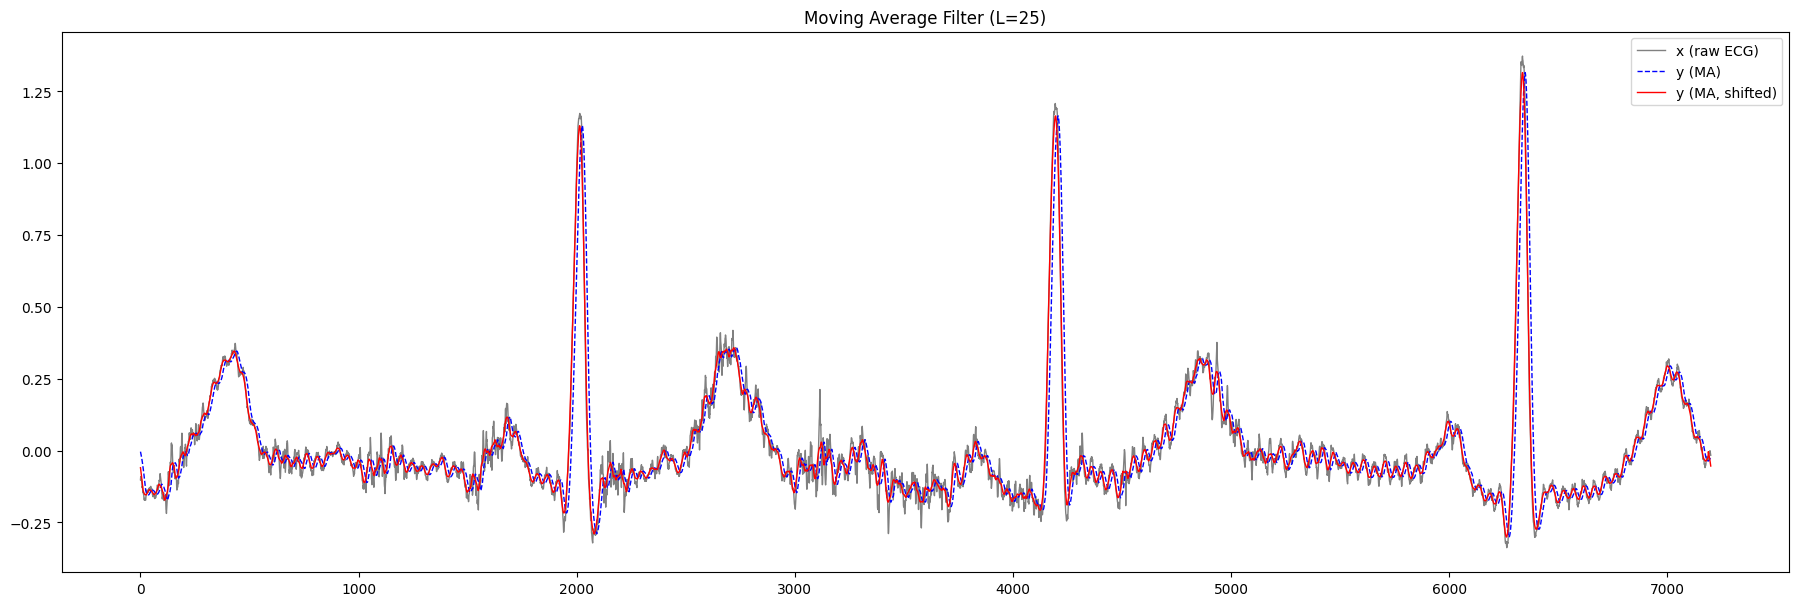

In [141]:
from scipy.signal import lfilter

L = 25 # amount of samples to average from previous exercise
h = np.ones(L) / L  # moving average filter
y = lfilter(h, 1, x)

delay = (L-1)//2 # calculate delay (integer devision for even L)
y_ = np.roll(y, -delay) #shift the array by delay positions

# Calculate SNR
signal_power = np.mean(y**2)
noise_power = np.mean((x - y)**2)
snr =  10 * np.log10(signal_power / noise_power) 

print(f"Output SNR = {snr:.2f} dB")

fig, axs = plt.subplots(1, 1, sharex='all', figsize=(18, 6))
fig.tight_layout()
axs.plot(k, x, lw=1.0, color='gray', label="x (raw ECG)") # raw ECG signal
axs.plot(k, y, lw=1.0, ls='--', color='blue', label="y (MA)") # without the delay
axs.plot(k, y_, lw=1.0, ls='-', color='red', label="y (MA, shifted)") # with the delay
axs.set_title("Moving Average Filter (L="+str(L)+")")

axs.legend()

plt.show()

# 3: IIR Filters
In this exercise, the goal is to apply 3 different IIr filters to time series data. 

There are three tasks here: 
1. Low-Pass-Filters: Butterworth Filters
2. Symmetric Filters
3. Notch Filters

We are defining the IIR Filter coefficients a and b for each and then filter with the coefficients.


## Importing Signal

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal


##%% Cell (1): loading test signal 
# Choose between the test signal by setting one of them to "True".

if True: # ECG SIGNAL 1: Real ECG Signal
    file_name = 'SECG3_FILT_HP51_3CH_20S_FS2400HZ.csv'
    fs = 2400  # sampling rate [Hz] of recorded signal
    K = fs*3  # number of samples to process. Here: fs*<number of seconds>
    k_start = 40000
    x = np.genfromtxt(file_name, usecols=(1), delimiter=r',', skip_header=0, )[k_start:k_start+K]
    

if False: # ECG SIGNAL 3: Real ECG Signal with 50Hz noise, high-frequency noise, and baseline
    file_name = 'SECG3_RAW_3CH_20S_FS2400HZ.csv'
    fs = 2400  # sampling rate [Hz] of recorded signal
    K = fs*4  # number of samples to process. Here: fs*<number of seconds>
    k_start = 1000
    x = np.genfromtxt(file_name, usecols=(1), delimiter=r',', skip_header=0, )[k_start:k_start+K]


# Add trailing ecg signal
if True: # Overwrites parts of ECG by a Synthetic Test signal
    #  (with Synthetic Rectangle at 0.5Hz)
    f = 3 # [Hz] Frequency of rectangular singnal
    K_ = int(fs*0.6)  # number of samples to process. Here: fs*<number of seconds>
    x_ = np.arange(K_)%(fs//f) < (0.5*fs//f) # generate rectangular test signal
    x[:K_] = x_

k = np.arange(K) # create time index vector

## Plotting Signal

Filename: SECG3_FILT_HP51_3CH_20S_FS2400HZ.csv
Number of loaded samples:  7200
Total signal duration [s]:  3.0
Signal shape (7200,)


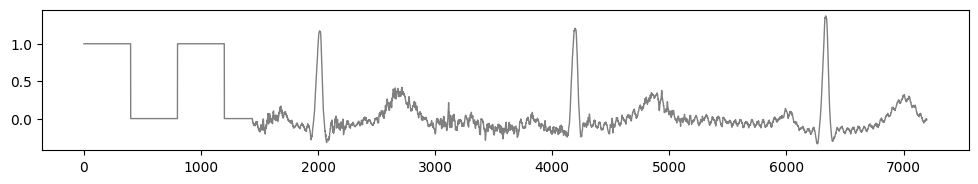

In [103]:
fig, axs = plt.subplots(1, 1, sharex='all', figsize=(10, 2))
fig.tight_layout()
axs.plot(k, x, lw=1.0, color='gray')

print("Filename:", file_name)
print("Number of loaded samples: ",K)
print("Total signal duration [s]: ", K/fs)
print("Signal shape "+str(x.shape))

## 3-1: Low-Pass Filter: Butterworth & 3-2
Trying to achieve the following things:
1. Create a 4th-order Butterworth low-pass filter with a cut-off frequency of 20 Hz. This filter will remove high-frequency components while keeping lower frequencies. Verify the filter's frequency response to ensure that at 20 Hz, the amplitude is reduced by -3 dB (which means 70.7% of the original amplitude remains).
Apply the filter to the signal and observe the changes.
2. Do you observe a phase shift (delay) in the filtered QRS waves?
3. By what factor is QRS amplitude reduced?


I included both exercises 3-1 and 3-2 here because I ran into the solution for 3-2 while working on 3-1.

### a) Create & Apply Filter & Verify 

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

plot_title = "Butterworth IIR Filter" 

#filter parameters
order = 4       # 4th-order Butterworth filter
fs = 2400       # Sampling frequency (in Hz)
fc = 20         # Cut-off frequency (in Hz)
nyquist = fs / 2  # Nyquist frequency

# Design Butterworth low-pass filter
b, a = butter(order, fc / nyquist, btype='low', analog=False) 


y_lfilter= lfilter(b, a, x) # applying filter to signal (with delay) = causal filtering
y_filtfilt = filtfilt(b, a, x) # filtering both ways = non-causal filtering



# Print filter coefficients
print("a (Denominator Coefficient -> IIR):", a, "\nb (Numerator Coefficients -> FIR):", b)


a (Denominator Coefficient -> IIR): [ 1.         -3.86318462  5.59883546 -3.60775245  0.87210865] 
b (Numerator Coefficients -> FIR): [4.39093236e-07 1.75637294e-06 2.63455941e-06 1.75637294e-06
 4.39093236e-07]


I adjusted the code for this cell because I wanted to see more clearly the cut-off at a frequency of 20 Hz with an amplitude dumping of -3dB. 

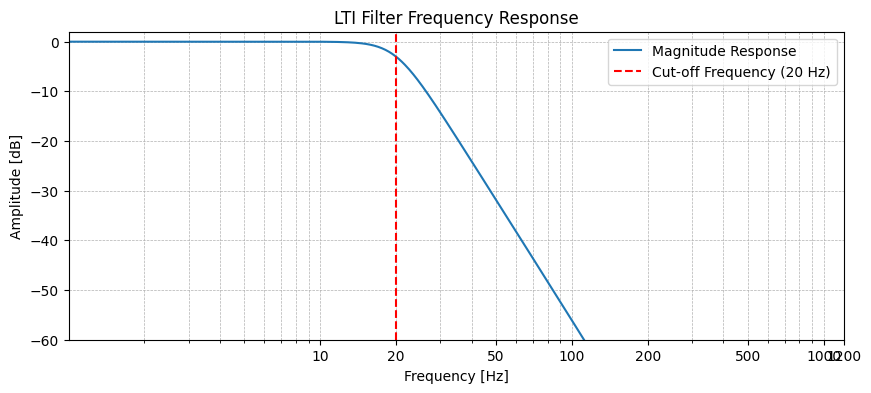

In [105]:
w, h = freqz(b, a, worN=2**12)
frequencies = w / (2 * np.pi) * fs  # Convert to Hz

# Plot Frequency Response
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(frequencies, 20 * np.log10(abs(h)), label="Magnitude Response")

# Highlight cut-off frequency at 20 Hz
ax.axvline(20, color='r', linestyle='--', label="Cut-off Frequency (20 Hz)")

# Axis labels and title
ax.set_title("LTI Filter Frequency Response")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude [dB]")

# Set y-axis limits (to focus on relevant range)
ax.set_ylim([-60, 2])

# Set x-axis limits and define custom tick marks for better readability
ax.set_xlim([1, fs / 2])  # From 1 Hz to Nyquist frequency
ax.set_xticks([10, 20, 50, 100, 200, 500, 1000, fs/2])  # Log-scale steps
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())  # Show actual values instead of scientific notation

# Enable grid (dashed lines for clarity)
ax.grid(which="both", linestyle="--", linewidth=0.5)

# Add legend
ax.legend()

# Show the plot
plt.show()


### b) Delay / Phase Shift
I did not observe a phase shift in both methods because I was using the filtfilt function from the scipy.signal module. An alternative would be to use the lfilter function.
- lfilter(b, a, x) → A function that applies a causal filter in a single forward pass, introducing a phase shift. -> this function introduces a delay
  - advantages: works in real-time (because it is  computationally faster due to being single pass)
- filtfilt(b, a, x) → A function that applies the filter twice (forward + backward), eliminating the phase shift. -> this function does not introduce a delay
  - advantages: no phase shift, smoother; but takes longer due to filtering twice

To visualize the differences, I plot y using both filter methods in one plot. 

/var/folders/1h/20qwddgj29lghmzyjxl8m6k80000gn/T/ipykernel_5689/2367371957.py:15: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


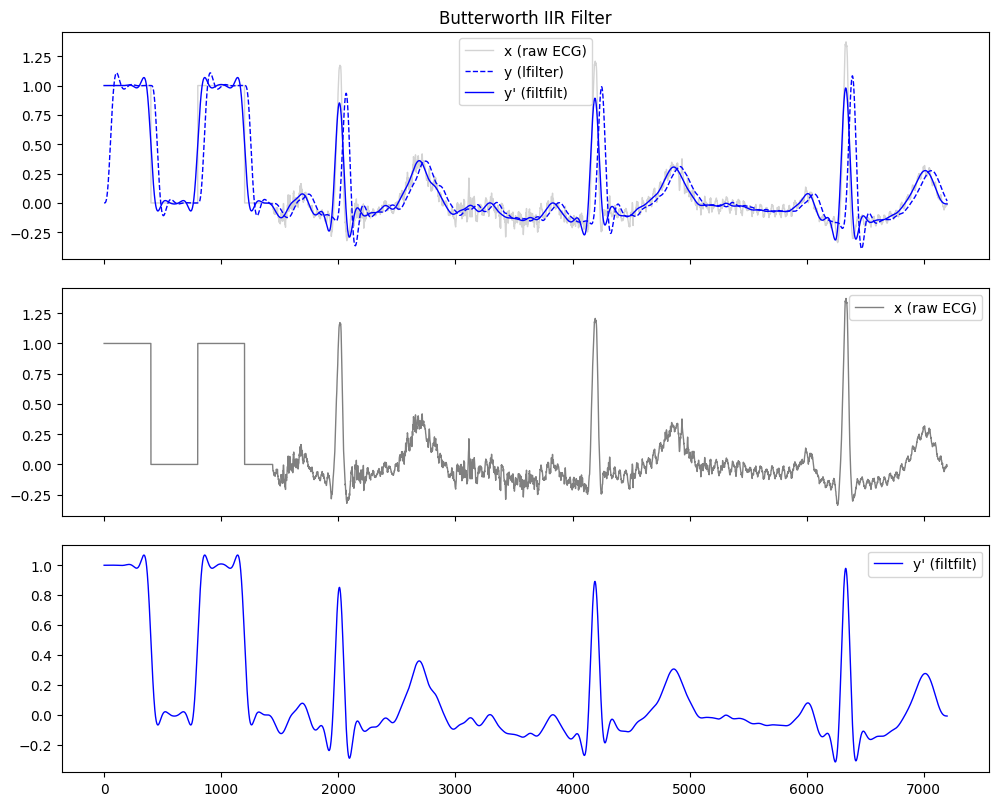

In [106]:
figs, axs = plt.subplots(3, 1, sharex='all', figsize=(10, 8))
figs.tight_layout()
axs[0].plot(k, x, lw=1.0, color='lightgray', label="x (raw ECG)")
axs[0].plot(k, y_lfilter, lw=1.0, ls='--', color='blue', label="y (lfilter)")
axs[0].plot(k, y_filtfilt, lw=1.0, ls='-', color='blue', label="y' (filtfilt)")
axs[0].set_title(plot_title)
axs[0].legend()

axs[1].plot(k, x, lw=1.0, color='gray', label="x (raw ECG)")
axs[1].legend()

axs[2].plot(k, y_filtfilt, lw=1.0, ls='-', color='blue', label="y' (filtfilt)")
axs[2].legend()

fig.show()



### c) Amplitude Reduction
I calculate the amplitude reduction for both the y from lfilter as the y from filtfilt. The amplitude reduction is greater for the lfilter than for the filtfilt. 
This is because:
- lfilter introduces a phase shift, causing misalignment and partial cancellation of peaks
- meanwhile filtfilt applies the filter forward and backward, canceling the phase shift and preserving the original signal’s alignment

In [107]:
original_amplitude = np.max(x) - np.min(x)

# Compute peak-to-peak amplitude after filtering (y_)
filtered_amplitude = np.max(y_lfilter) - np.min(y_lfilter)

# Compute the amplitude reduction factor
amplitude_reduction_factor = filtered_amplitude / original_amplitude

# Print the result
print(f"Original Amplitude: {original_amplitude:.3f}")
print(f"Filtered Amplitude: {filtered_amplitude:.3f}")
print(f"Amplitude Reduction Factor: {amplitude_reduction_factor:.3f}")

Original Amplitude: 1.710
Filtered Amplitude: 1.498
Amplitude Reduction Factor: 0.876


In [108]:
original_amplitude = np.max(x) - np.min(x)

# Compute peak-to-peak amplitude after filtering (y_)
filtered_amplitude = np.max(y_filtfilt) - np.min(y_filtfilt)

# Compute the amplitude reduction factor
amplitude_reduction_factor = filtered_amplitude / original_amplitude

# Print the result
print(f"Original Amplitude: {original_amplitude:.3f}")
print(f"Filtered Amplitude: {filtered_amplitude:.3f}")
print(f"Amplitude Reduction Factor: {amplitude_reduction_factor:.3f}")


Original Amplitude: 1.710
Filtered Amplitude: 1.384
Amplitude Reduction Factor: 0.809


## 3-3: Notch Filters
Notch filters are used to remove a specific narrow frequency band while keeping the rest of the signal intact. They are ideal for removing persistent, unwanted frequencies like electrical noise or specific interference signals.
- example use case: Removing Power Line Interference (50/60 Hz) -> In ECG, EEG, and other biomedical signals, power line noise (50 Hz in Europe, 60 Hz in the US) can contaminate recordings.

1. Work with test signal ECG SIGNAL 2 which is showing strong 50Hz interferences. Check the manual for scipy.signals.iirnotch(...) and modify the code in Cell (2) accordingly. Verify the result also on the synthetic test signal sequence.
2. By what factor is QRS amplitude reduced?

### Import Signal

In [109]:
if True: # ECG SIGNAL 2: Real ECG Signal with 50Hz noise and baseline (for exercise 3-3)
    file_name = 'SECG3_RAW_3CH_20S_FS2400HZ.csv'
    fs = 2400  # sampling rate [Hz] of recorded signal
    K = fs*4  # number of samples to process. Here: fs*<number of seconds>
    k_start = 1000
    x = np.genfromtxt(file_name, usecols=(1), delimiter=r',', skip_header=0, )[k_start:k_start+K]


# Add trailing ecg signal
if True: # Overwrites parts of ECG by a Synthetic Test signal
    #  (with Synthetic Rectangle at 0.5Hz)
    f = 3 # [Hz] Frequency of rectangular singnal
    K_ = int(fs*0.6)  # number of samples to process. Here: fs*<number of seconds>
    x_ = np.arange(K_)%(fs//f) < (0.5*fs//f) # generate rectangular test signal
    x[:K_] = x_

k = np.arange(K) # create time index vector

### Plot Signal

Filename: SECG3_RAW_3CH_20S_FS2400HZ.csv
Number of loaded samples:  9600
Total signal duration [s]:  4.0
Signal shape (9600,)


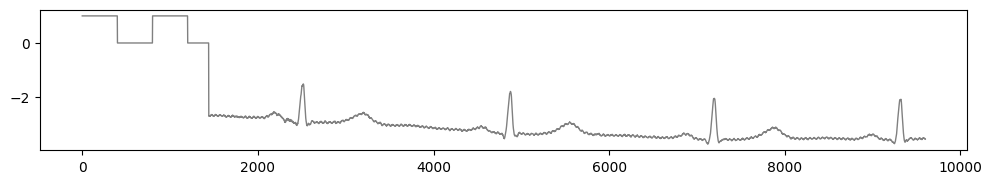

In [110]:
fig, axs = plt.subplots(1, 1, sharex='all', figsize=(10, 2))
fig.tight_layout()
axs.plot(k, x, lw=1.0, color='gray')

print("Filename:", file_name)
print("Number of loaded samples: ",K)
print("Total signal duration [s]: ", K/fs)
print("Signal shape "+str(x.shape))

### Define Filter Parameters

In [111]:
fs = 2400  # Sampling frequency (Hz)
f0 = 50    # Notch frequency (Hz) -> to be removed (power lines?)
Q = 30     # Quality factor (adjust for sharpness of notch)

### Apply Filter

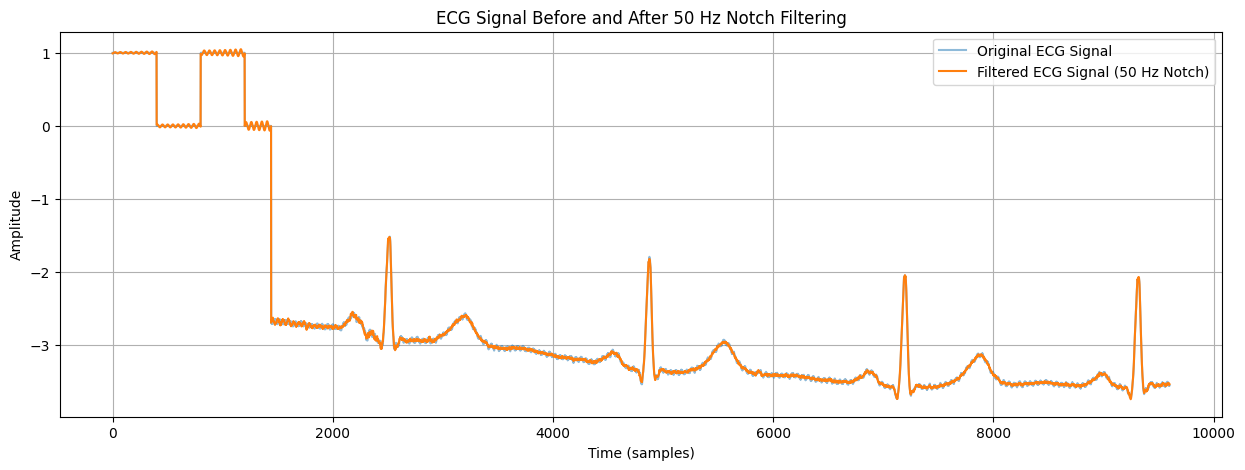

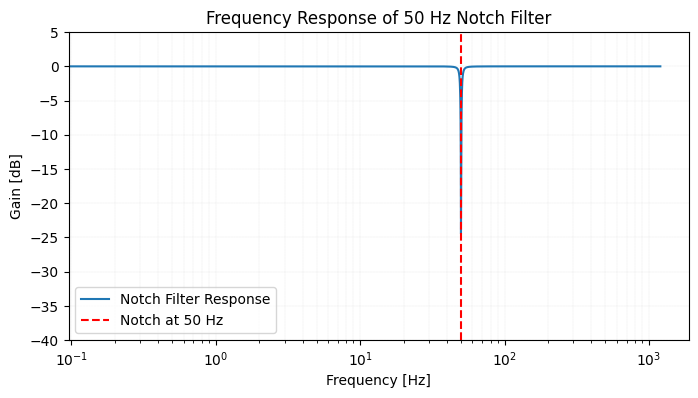

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt

# Design the Notch filter
b, a = iirnotch(f0, Q, fs)

y_ = filtfilt(b, a, x)  # Zero-phase filtering to avoid phase shift


plt.figure(figsize=(15, 5))
plt.plot(x, label="Original ECG Signal", alpha=0.5)
plt.plot(y_, label="Filtered ECG Signal (50 Hz Notch)")
plt.title("ECG Signal Before and After 50 Hz Notch Filtering")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()


from scipy.signal import freqz
w, h = freqz(b, a, worN=8000)
frequencies = w / (2 * np.pi) * fs  # Convert to Hz

plt.figure(figsize=(8, 4))
plt.semilogx(frequencies, 20 * np.log10(abs(h)), label="Notch Filter Response")
plt.axvline(f0, color='r', linestyle='--', label="Notch at 50 Hz")
plt.title("Frequency Response of 50 Hz Notch Filter")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain [dB]")
plt.ylim([-40, 5])
plt.grid(which="both", linestyle="--", linewidth=0.1)
plt.legend()
plt.show()

### b) Amplitude Reduction

In [113]:
original_amplitude = np.max(x) - np.min(x)
filtered_amplitude = np.max(y_) - np.min(y_)
amplitude_reduction_factor = filtered_amplitude / original_amplitude

# Print results
print(f"Original Amplitude: {original_amplitude:.3f}")
print(f"Filtered Amplitude: {filtered_amplitude:.3f}")
print(f"Amplitude Reduction Factor: {amplitude_reduction_factor:.3f}")

Original Amplitude: 4.726
Filtered Amplitude: 4.785
Amplitude Reduction Factor: 1.012


# 4: Detection of Neural Spikes
Spike detection and sorting are essential for analyzing neural activity, identifying patterns in brain function, and diagnosing disorders like epilepsy. They enable precise mapping of neural responses, crucial for brain-computer interfaces and medical research. Reliable sorting methods must account for noise and signal distortions to ensure accurate data interpretation.

- Why? Researchers can study neural circuits, detect abnormalities in neurological disorders (e.g., epilepsy), and develop brain-computer interfaces for assistive technologies.
- How? Spike trains are recorded with micro electrodes placed on the cortex. It is known that spikes generated by every neurone have their own characteristic shape.

Info from the CSV:

- Column 1: sample index (int)
- Column 2: signal sample value (float)
- Column 3: binary flag indicating start indexes of new spikes: "1" if a new spike starts at this sample index, 0 otherwise (Bool)
  - to see where a new spike starts
- Column 4: Source Neuron 1, 2, or 3 (Ground Truth) (Int)
  - to verify results



## 4-1: Spike Detection
The goal is to detect all spikes in a signal that have a similar shape to the reference spike from Neuron 1. The detection is based on a log-cost ratio based on the Euclidean distance measure. 


In [114]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

FILENAME = "1D Exercises/dbm-Lab4-distances-measures/csv/pulsed-signals-01-no-artifact.csv"
SLICE_WIDTH = 50 # spike with; length of a single spike
SAVE_FIGURE = False # True: saves figure as a .PNG file (for documentation)

### CSV-Helper Function
This function loads a signal from the CSV file.

In [115]:
def load_CSV(filename):
    """
    Loads a single signal from the CSV file named filename. 

    Expected CSV File Format: 
    - Column 0: Sample Index k (int)
    - Column 1: Sample Value y_k (float)
    - Column 2: Sample index of spike beginning (0: no spike, 1: first sample of a new spike)
    - Column 3: Source neuron cluster 1,2,3,... (int)
  
    Parameters
    ----------
    filename : string
               CSV filename e.g. "data.csv"
               
    Returns
    -------
    y  : numpy.ndarray of floats of shape (K,)
         Loaded sample data
    is_spike: numpy.ndarray of bool of shape (K,)
         indicates if a spike starts at this time index. "True" or "False". 
    neuron_source: numpy.ndarray of float (K,)
         indicates neuron source clustr 1,2,3,... for each time index (=Ground Truth). 0 for no neuron. 

    with
    NOF_SPIKES: number of pulses
    K: number of samples in the observed signal y. 
    """
    ys_csv = np.loadtxt(FILENAME, delimiter=',') # load CSV
    index_k = ys_csv[:,0] # extract sample indices
    y = ys_csv[:,1] # extract signal samples y
    is_spike = (ys_csv[:,2]>0) # True for spike start at this index; False otherwise
    neuron_source = ys_csv[:,3].astype(int) # source neuron index 1, 2, 3, ...
    return (y, is_spike, neuron_source)

### Extractor-Helper Function
Helps extract signal slices from the signal y, starting at inices k0s.

In [116]:
def extract_slices(y, k0s, SLICE_WIDTH):
    """
    Extracts signal slices form signal y, starting at indices k0s and each slice is of length SLICE_WIDTH
    
    Parameters
    ----------
    y   : array_like of floats of shape=(K)
          observed signal of length K
    k0s : list of ints length NOF_SLICES 
          list with start indices of each slice
    SLICE_WIDTH : int
        length of a single slices

    Returns
    -------
    s  : numpy.ndarray of shape=shape of (NOF_SLICES, SLICE_WIDTH) of floats`
         each row contains the samples of a single slice, i.e. of a single neural spike
  
    with

    NOF_SPIKES: number of slices
    SLICE_WIDTH: slice length 
    K: number of samples in the observed signal y.  
    """ 
    
    NOF_SLICES = len(k0s) # number of spikes
    LEN_Y = len(y)
    z_slices = np.zeros( (NOF_SLICES, SLICE_WIDTH) ) # memory for spikes
    for p in range(NOF_SLICES): # cut out each slice (=neural spike)
       if (k0s[p]+SLICE_WIDTH >= LEN_Y): # prevents accessing array indices out of range
           continue
       z_slices[p, :] = y[k0s[p]:k0s[p]+SLICE_WIDTH] # cuts out a single slice
    return (z_slices)

## Detection

### Setting the LCR-Threshold
Setting the LCR-Threshold for the detection of neural spikes is important. It measures how similar each spike is to the reference spike.
- Higher LCR: very similar to the reference.
- Lower (more negative) LCR: very different.
By setting the threshold, we decide at what LCR value we accept a spike as a match.
-> If the threshold is too high, I might miss some valid spikes, but if it is too low I might identify noise as spikes -> the ideal threshold needs to be found. 

I initially tried a low threshold of -3.5. It identified all the spikes in the ECG, but not only the ones that resemble neuron 1, meaning that it was too low. 
Then I saw in the exercise description that 1 was the ideal LCR-threshold, so I used that. But it falsely identified a wrong spike. With regard to the plot, I chose an LCR threshold of 1.8 and it correctly identified all the spikes.

LCR: **identifies a likelihood / probability!**

![LCR Threshold](LCR-threshold.png)

### Slicing & LCR Application

In [117]:
y, is_pulse, neuron_sources = load_CSV(FILENAME)
K = y.shape[0]
k = np.arange(K)

# Find reference spike
REF_INDEX = np.where(is_pulse)[0][0] # index of first spike we want to identify
z_ref = y[REF_INDEX:REF_INDEX + SLICE_WIDTH] # reference spike

# Extract signal slices -> because we don't know indices of spikes, we give all indices to the function -> will be like a sliding window
zs = extract_slices(y, k, SLICE_WIDTH)

# squared Euclidean distance
squared_differences = (zs - z_ref) ** 2
distances_sq = np.sum(squared_differences, axis=1)

# energy of slice
shape_energy = np.sum(zs ** 2, axis=1)

with np.errstate(divide='ignore', invalid='ignore'):
    lcr = -0.5 * np.log(np.maximum(distances_sq / shape_energy, 1e-10)) # log argument is never smaller than 1e-10 to avoid division by zero


# Find peaks in LCR to detect spikes
LCR_THRESHOLD = 1.8
peaks, _ = scipy.signal.find_peaks(lcr, height=LCR_THRESHOLD)
indices_spikes_detected = k[peaks]

### Plotting Results

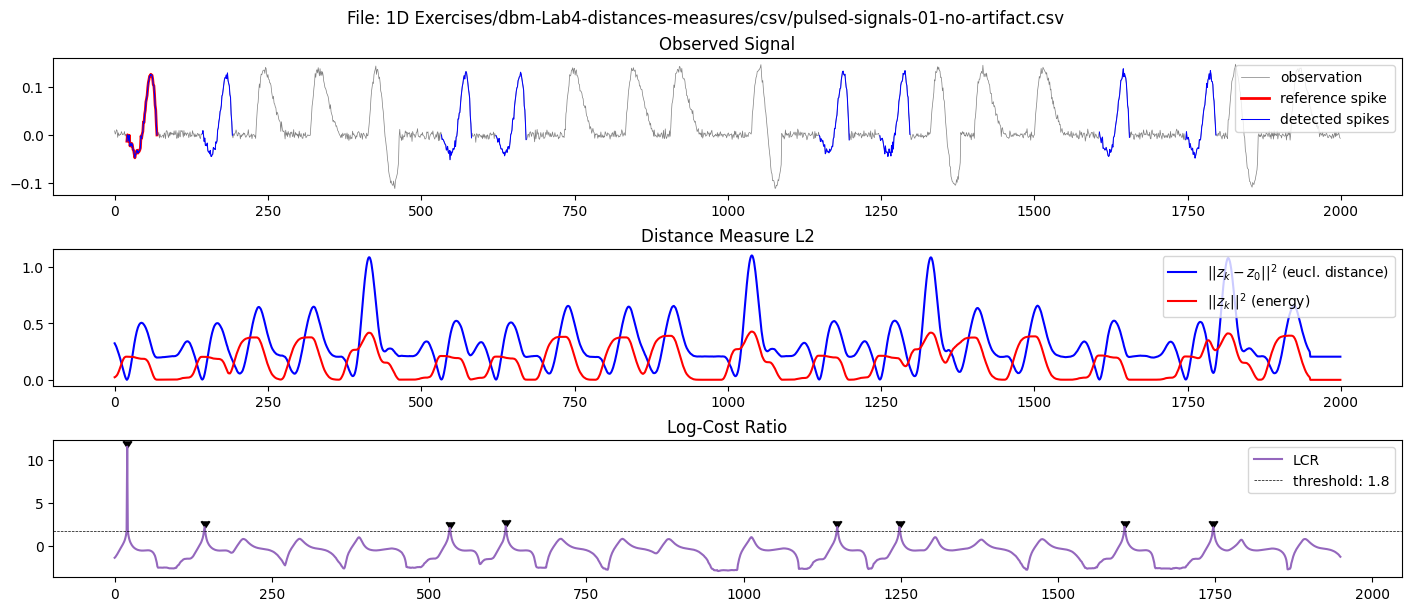

In [118]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), constrained_layout=True)
plt.suptitle("File: " + FILENAME)

# -- Subplot 0 : plot signal with reference pulse and detected pulses --
axes[0].set_title("Observed Signal")
axes[0].plot(k, y, lw=0.5, c='tab:gray')
axes[0].plot(range(SLICE_WIDTH) + REF_INDEX, y[range(SLICE_WIDTH) + REF_INDEX], lw=2.0, c='r')
for k0 in indices_spikes_detected:
    axes[0].plot(range(SLICE_WIDTH) + k0, y[range(SLICE_WIDTH) + k0], lw=0.75, c='b')
axes[0].legend(["observation", "reference spike", "detected spikes"], loc="upper right")

# -- Subplot 1 : plot distance measures  --
axes[1].set_title("Distance Measure L2")
axes[1].plot(k, distances_sq, 'b', label="$||z_k - z_0||^2$ (eucl. distance)")
axes[1].plot(k, shape_energy, 'r', label="$||z_k||^2$ (energy)")
axes[1].legend(loc="upper right")

# -- Subplot 2 : plot LCR with threshold (dashed line) --
axes[2].set_title("Log-Cost Ratio")
axes[2].plot(k, lcr, color="tab:purple", label="LCR")
axes[2].axhline(y=LCR_THRESHOLD, ls='--', lw=0.5, c='k', label=f"threshold: {LCR_THRESHOLD}")
axes[2].scatter(indices_spikes_detected, lcr[peaks], marker=7, c='k')
axes[2].legend(loc="upper right")

plt.show()

In this plot, we can see the following things:
- Subplot 1: The method correctly identifies and highlights spikes that are similar to the reference spike, confirming that the detection process works.
- Subplot 2: 
  - Blue line: Euclidian Distance -> the larger the distance (= peaks in blue line), the less similar to the reference 
  - Red line is the energy. We include this, because we use it to normalise for the LCR, otherwise the same shape of a spike would not be recognized if it had a different size based on euclidian distance alone! 
- Subplot 3: Spikes with LCR above the threshold are considered detected. The threshold is well-positioned since it correctly identifies neural spikes while filtering out noise.


What does this mean for me?
- The spike detection algorithm successfully finds spikes that match the reference.
- The distance and LCR measures support accurate identification.
- The detection method appears robust.

## 4-2: Spike Sorting


Helper functions are the same as the previous ones

In [119]:
import numpy as np
import matplotlib.pyplot as plt

SPIKE_WIDTH = 50 # spike with; length of a single spike
REF_INDEX = 0 # spike index of reference spike, i.e. spike cluster to identify

SAVE_FIGURE = False # True: saves figure as a .PNG file (for documentation)

### Defining Functions for Distances
Here, I define functions to compute the following 4 distances:
- Euclidean Distance: straight line distance -> use when raw differences matter
- Scale-Invariant Distance: normalizes vectors before computing Euclidean distance -> use when only shape matters
- Cosine Distance: measures the angle between two vectors rather than their magnitude -> use when directionality is more important than magnitude 
- Mean-Centered Distance: Subtracts the mean before computing Euclidean distance, making it focus on shape rather than absolute values -> use when comparing deviations rather than absolute values


I ended up only using euclidian_distance and scale_invariant_distance.

In [120]:
def euclidean_distance(a, b):
    """ Computes Euclidean distance between two vectors. """
    return np.linalg.norm(a - b)

def scale_invariant_distance(a, b):
    """ Normalizes signals and computes Euclidean distance. """
    a_norm = a / np.linalg.norm(a)
    b_norm = b / np.linalg.norm(b)
    return np.linalg.norm(a_norm - b_norm)

def cosine_distance(a, b):
    """ Computes cosine similarity-based distance. """
    return 1 - np.inner(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def mean_centered_distance(a, b):
    """ Computes distance between mean-centered signals. """
    a_centered = a - np.mean(a)
    b_centered = b - np.mean(b)
    return np.linalg.norm(a_centered - b_centered)

### Variable Dictionary
Because the next few exercises will be quite long and confusing, I pasted a variable dictionary for myself here to help remember which variable to use.

![VAR DICTIONARY](var_dictionary.png)

### a) No Artifact
Clean spike train recording with only very little artifacts.

**Euclidian Distance** -> worked well for this sample, because it was very clean, few artifacts, similar amplitude of the signals etc.

In [121]:
FILENAME = "1D Exercises/dbm-Lab4-distances-measures/csv/pulsed-signals-01-no-artifact.csv"

#### Loading Signal, Performing Slicing & Finding Reference Indices

In [122]:
(y, is_spike, neuron_sources) = load_CSV(FILENAME)
K = y.shape[0] 
indices_spikes = np.where(is_spike != False)[0]  

zs = extract_slices(y, indices_spikes, SPIKE_WIDTH)  
NOF_SPIKES = zs.shape[0]  

REF_INDEX = {}

for neuron_id in [1, 2, 3]:
    first_spike_index = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    if first_spike_index is not None:
        REF_INDEX[neuron_id] = np.where(indices_spikes == first_spike_index)[0][0]  # Convert to slice index

print("Reference indices (slice numbers) for each neuron:", REF_INDEX) #important for identification of reference spike

THRESHOLDS = {1: 0.15, 2: 0.15, 3: 0.15}  # Define thresholds for each neuron -> that way we can adjust them individually

Reference indices (slice numbers) for each neuron: {1: 0, 2: 2, 3: 4}


#### Plotting the Spike Detection & Euclidian Distance

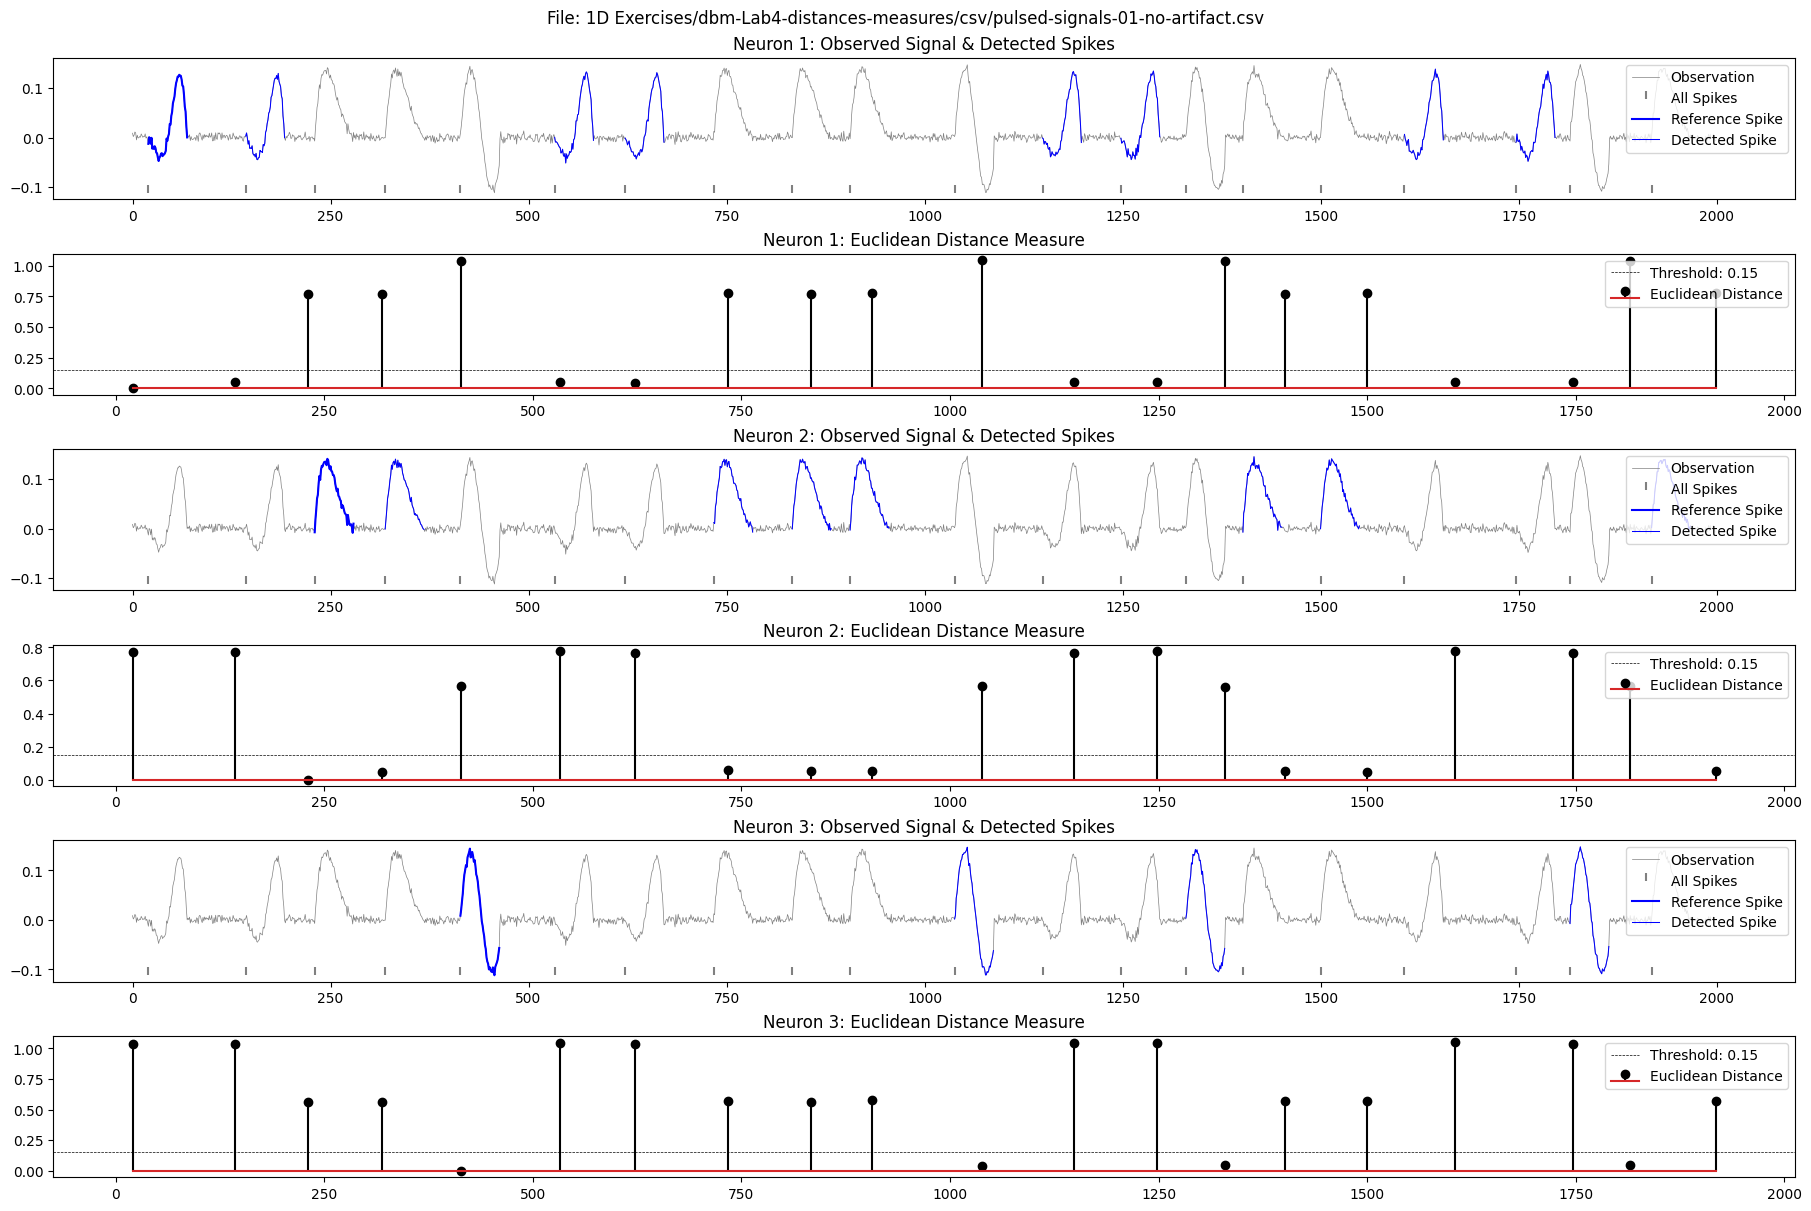

In [123]:
fig, axes = plt.subplots(len(REF_INDEX) * 2, 1, figsize=(18, 4 * len(REF_INDEX)), constrained_layout=True)
plt.suptitle(f"File: {FILENAME}")

for idx, neuron_id in enumerate(REF_INDEX.keys()): #using a loop to iterate over all neurons
    ref_idx = REF_INDEX[neuron_id]  # Get reference index for this neuron (this is the slice number we identified earlier)
    threshold = THRESHOLDS[neuron_id]  # Get threshold for this neuron
    
    # Compute Euclidean distances
    distances_euclidean = np.array([euclidean_distance(zs[ref_idx], zs[i]) for i in range(NOF_SPIKES)])
    
    # Detect spikes for the neuron
    indices_spikes_detected = [k0 for k0, dist in zip(indices_spikes, distances_euclidean) if neuron_sources[k0] == neuron_id and dist < threshold]
    
    # Select reference spike for the neuron
    reference_spike = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    
    # Observed Signal & Detected Spikes
    ax_signal = axes[idx * 2]
    ax_signal.set_title(f"Neuron {neuron_id}: Observed Signal & Detected Spikes")
    ax_signal.plot(range(K), y, lw=0.5, c='gray', label='Observation')
    ax_signal.scatter(indices_spikes, np.ones_like(indices_spikes) * y.min(), marker=2, c='gray', label="All Spikes")  
    if reference_spike is not None:
        ax_signal.plot(range(SPIKE_WIDTH) + reference_spike, y[range(SPIKE_WIDTH) + reference_spike], lw=1.5, c='b', label='Reference Spike')  
    
    for k0 in indices_spikes_detected:  
        ax_signal.plot(range(SPIKE_WIDTH) + k0, y[range(SPIKE_WIDTH) + k0], lw=0.75, c='blue', label='Detected Spike' if k0 == indices_spikes_detected[0] else "")
    
    ax_signal.legend(loc="upper right")
    
    # Distance Measure Plot
    ax_distance = axes[idx * 2 + 1]
    ax_distance.set_title(f"Neuron {neuron_id}: Euclidean Distance Measure")
    ax_distance.stem(indices_spikes, distances_euclidean, 'k', markerfmt='ko', linefmt='k-', label='Euclidean Distance')
    ax_distance.axhline(y=threshold, ls='--', lw=0.5, c='k', label=f"Threshold: {threshold}")
    ax_distance.legend(loc="upper right")

plt.show()

Learnings:
- In this first example, with a clean spike train recording, it worked well using the euclidian distance. Here, it doesn't matter so much, because we have spikes that are all roughly the same size, so we can use a measure that takes shape & amplitude into account.

### b) Variable Spike Amplitudes
In this sample, the spike amplitudes vary due to altering distances between the sensor and the neurone.

Due to knowing this, I will be using the **scale-invariant distance** to identify the neurons.

In [124]:
FILENAME = "1D Exercises/dbm-Lab4-distances-measures/csv/pulsed-signals-02-motion-artifact.csv"

#### Loading Signal, Performing Slicing & Finding Reference Indices

In [125]:
(y, is_spike, neuron_sources) = load_CSV(FILENAME)
K = y.shape[0] 
indices_spikes = np.where(is_spike != False)[0]  

zs = extract_slices(y, indices_spikes, SPIKE_WIDTH)  
NOF_SPIKES = zs.shape[0]  

REF_INDEX = {}

for neuron_id in [1, 2, 3]:
    first_spike_index = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    if first_spike_index is not None:
        REF_INDEX[neuron_id] = np.where(indices_spikes == first_spike_index)[0][0]  # Convert to slice index

print("Reference indices (slice numbers) for each neuron:", REF_INDEX) #important for identification of reference spike

THRESHOLDS = {1: 0.55, 2: 0.5, 3: 0.3}  # Define thresholds for each neuron -> that way we can adjust them individually

Reference indices (slice numbers) for each neuron: {1: 0, 2: 2, 3: 4}


#### Plotting the Spike Detection & Scale-Invariant Distance

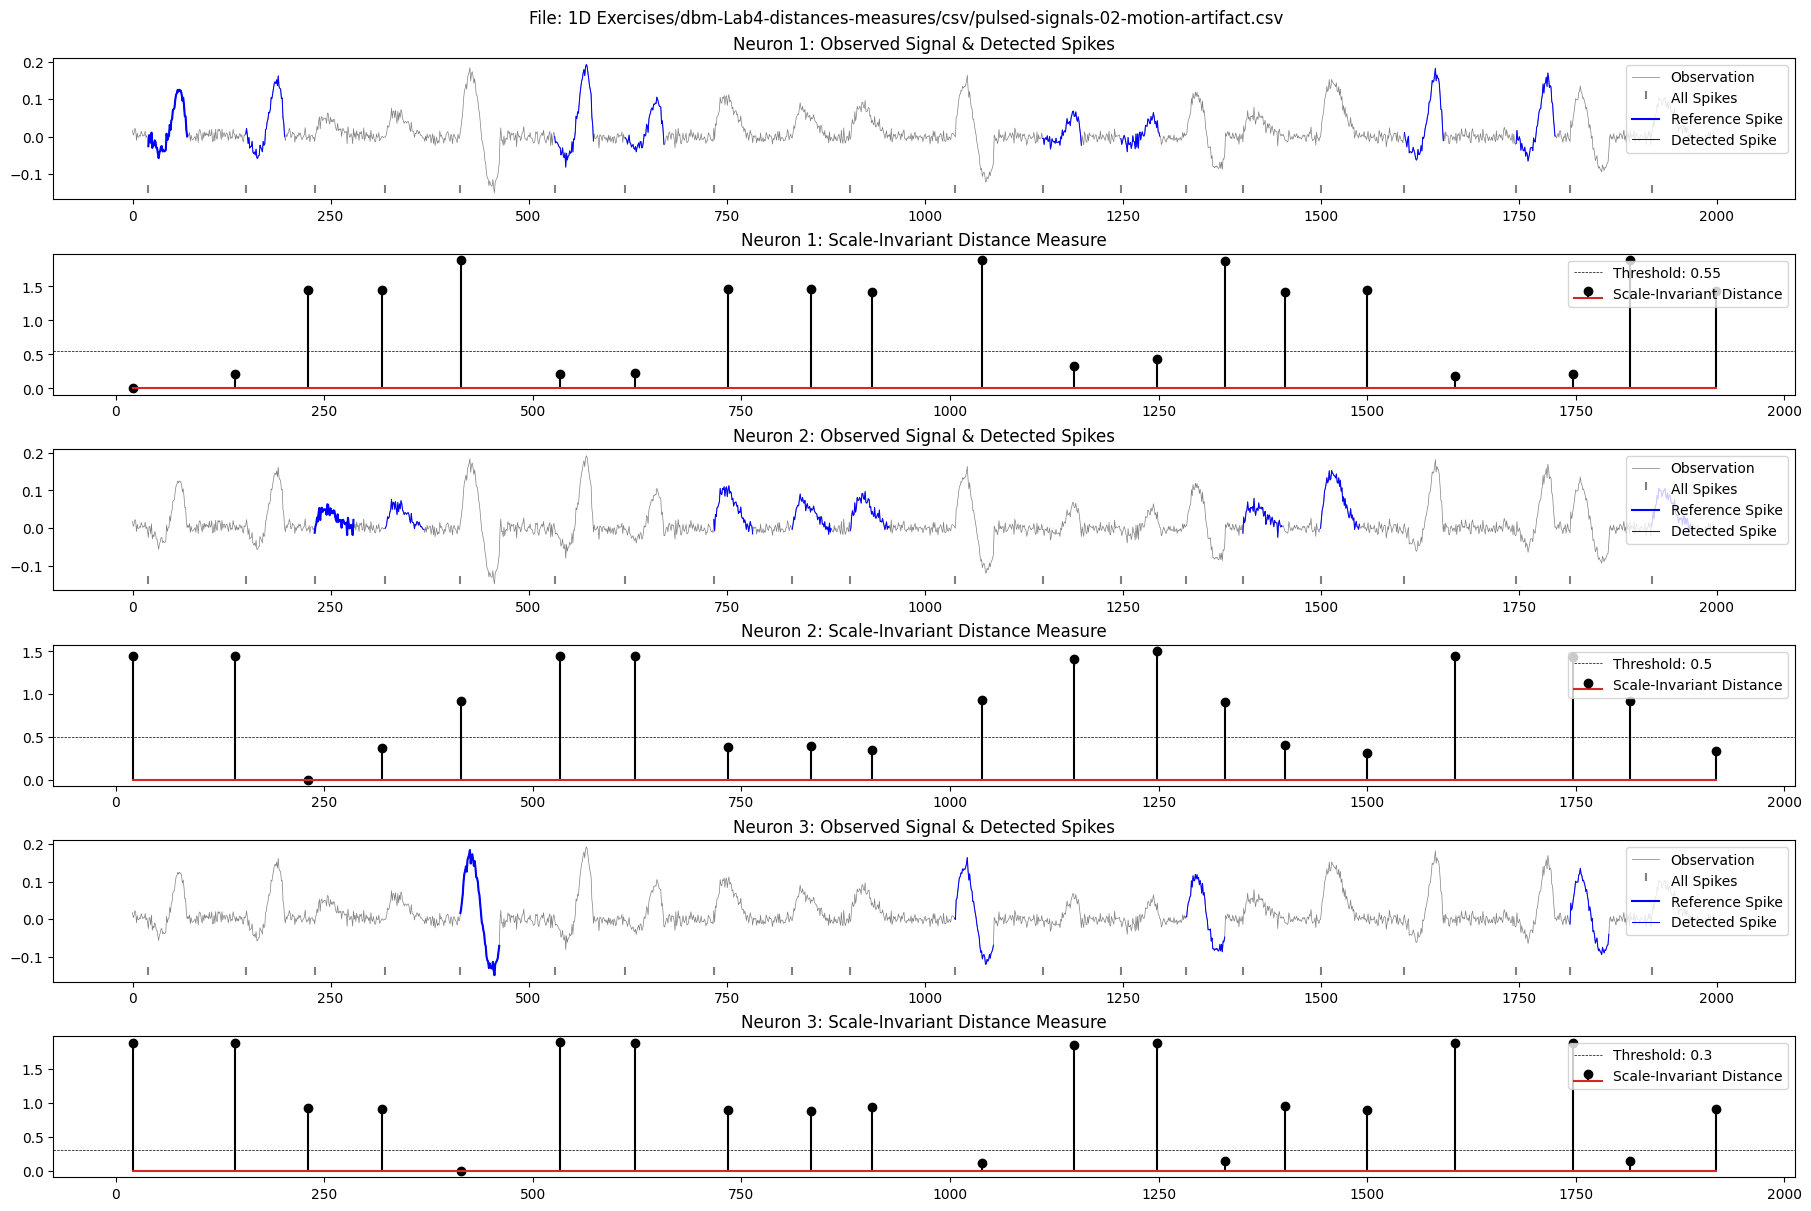

In [126]:
fig, axes = plt.subplots(len(REF_INDEX) * 2, 1, figsize=(18, 4 * len(REF_INDEX)), constrained_layout=True)
plt.suptitle(f"File: {FILENAME}")

for idx, neuron_id in enumerate(REF_INDEX.keys()):  # Loop through all neurons
    ref_idx = REF_INDEX[neuron_id]  # Get reference index for this neuron
    threshold = THRESHOLDS[neuron_id]  # Get threshold for this neuron
    
    # Compute scale-invariant distances
    distances_scaled = np.array([scale_invariant_distance(zs[ref_idx], zs[i]) for i in range(NOF_SPIKES)])
    
    # Detect spikes for the neuron
    indices_spikes_detected = [
        k0 for k0, dist in zip(indices_spikes, distances_scaled)
        if neuron_sources[k0] == neuron_id and dist < threshold
    ]
    
    # Select reference spike for the neuron
    reference_spike = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    
    # Observed Signal & Detected Spikes
    ax_signal = axes[idx * 2]
    ax_signal.set_title(f"Neuron {neuron_id}: Observed Signal & Detected Spikes")
    ax_signal.plot(range(K), y, lw=0.5, c='gray', label='Observation')
    ax_signal.scatter(indices_spikes, np.ones_like(indices_spikes) * y.min(), marker=2, c='gray', label="All Spikes")  
    
    if reference_spike is not None:
        ax_signal.plot(range(SPIKE_WIDTH) + reference_spike, y[range(SPIKE_WIDTH) + reference_spike], lw=1.5, c='b', label='Reference Spike')  
    
    for k0 in indices_spikes_detected:  
        ax_signal.plot(range(SPIKE_WIDTH) + k0, y[range(SPIKE_WIDTH) + k0], lw=0.75, c='blue', label='Detected Spike' if k0 == indices_spikes_detected[0] else "")
    
    ax_signal.legend(loc="upper right")
    
    # Distance Measure Plot
    ax_distance = axes[idx * 2 + 1]
    ax_distance.set_title(f"Neuron {neuron_id}: Scale-Invariant Distance Measure")
    ax_distance.stem(indices_spikes, distances_scaled, 'k', markerfmt='ko', linefmt='k-', label='Scale-Invariant Distance')
    ax_distance.axhline(y=threshold, ls='--', lw=0.5, c='k', label=f"Threshold: {threshold}")
    ax_distance.legend(loc="upper right")

plt.show()


As we can see, the result with the scale-invariant distance is good, we can achieve a good spike sorting. 

### c) Variable Spike Amplitudes & Possible Spike Inversion
Similar to the last exercise, I tried using the scale-invariant distance, but this time with inversion.

In [127]:
FILENAME = "1D Exercises/dbm-Lab4-distances-measures/csv/pulsed-signals-03-motion-artifact-inversion.csv"

#### Function Scale-invariant with Inversion
To handle the reversed polarity, this function computes the Euclidean distance between the normalized signals in both their original and inverted forms. 
It then returns only the smaller one of the two distances, like this the function ensures that spikes are detected regardless of whether their polarity has been reversed, making the method robust to signal distortions.

In [128]:
def scale_invariant_distance_with_inversion(a, b):
    a_norm = a / np.linalg.norm(a)
    b_norm = b / np.linalg.norm(b)
    b_inv_norm = -b_norm  # Inverted polarity
    
    return min(np.linalg.norm(a_norm - b_norm), np.linalg.norm(a_norm - b_inv_norm)) # returns the smaller of the two

#### Loading Signal, Performing Slicing & Finding Reference Indices

In [129]:
(y, is_spike, neuron_sources) = load_CSV(FILENAME)
K = y.shape[0] 
indices_spikes = np.where(is_spike != False)[0]  

zs = extract_slices(y, indices_spikes, SPIKE_WIDTH)  
NOF_SPIKES = zs.shape[0]  

REF_INDEX = {}

for neuron_id in [1, 2, 3]:
    first_spike_index = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    if first_spike_index is not None:
        REF_INDEX[neuron_id] = np.where(indices_spikes == first_spike_index)[0][0]  # Convert to slice index

print("Reference indices (slice numbers) for each neuron:", REF_INDEX) #important for identification of reference spike

THRESHOLDS = {1: 0.55, 2: 0.5, 3: 0.3}  # Define thresholds for each neuron -> that way we can adjust them individually

Reference indices (slice numbers) for each neuron: {1: 0, 2: 2, 3: 4}


#### Plotting the Spike Detection & Scale-Invariant Distance with Inversion

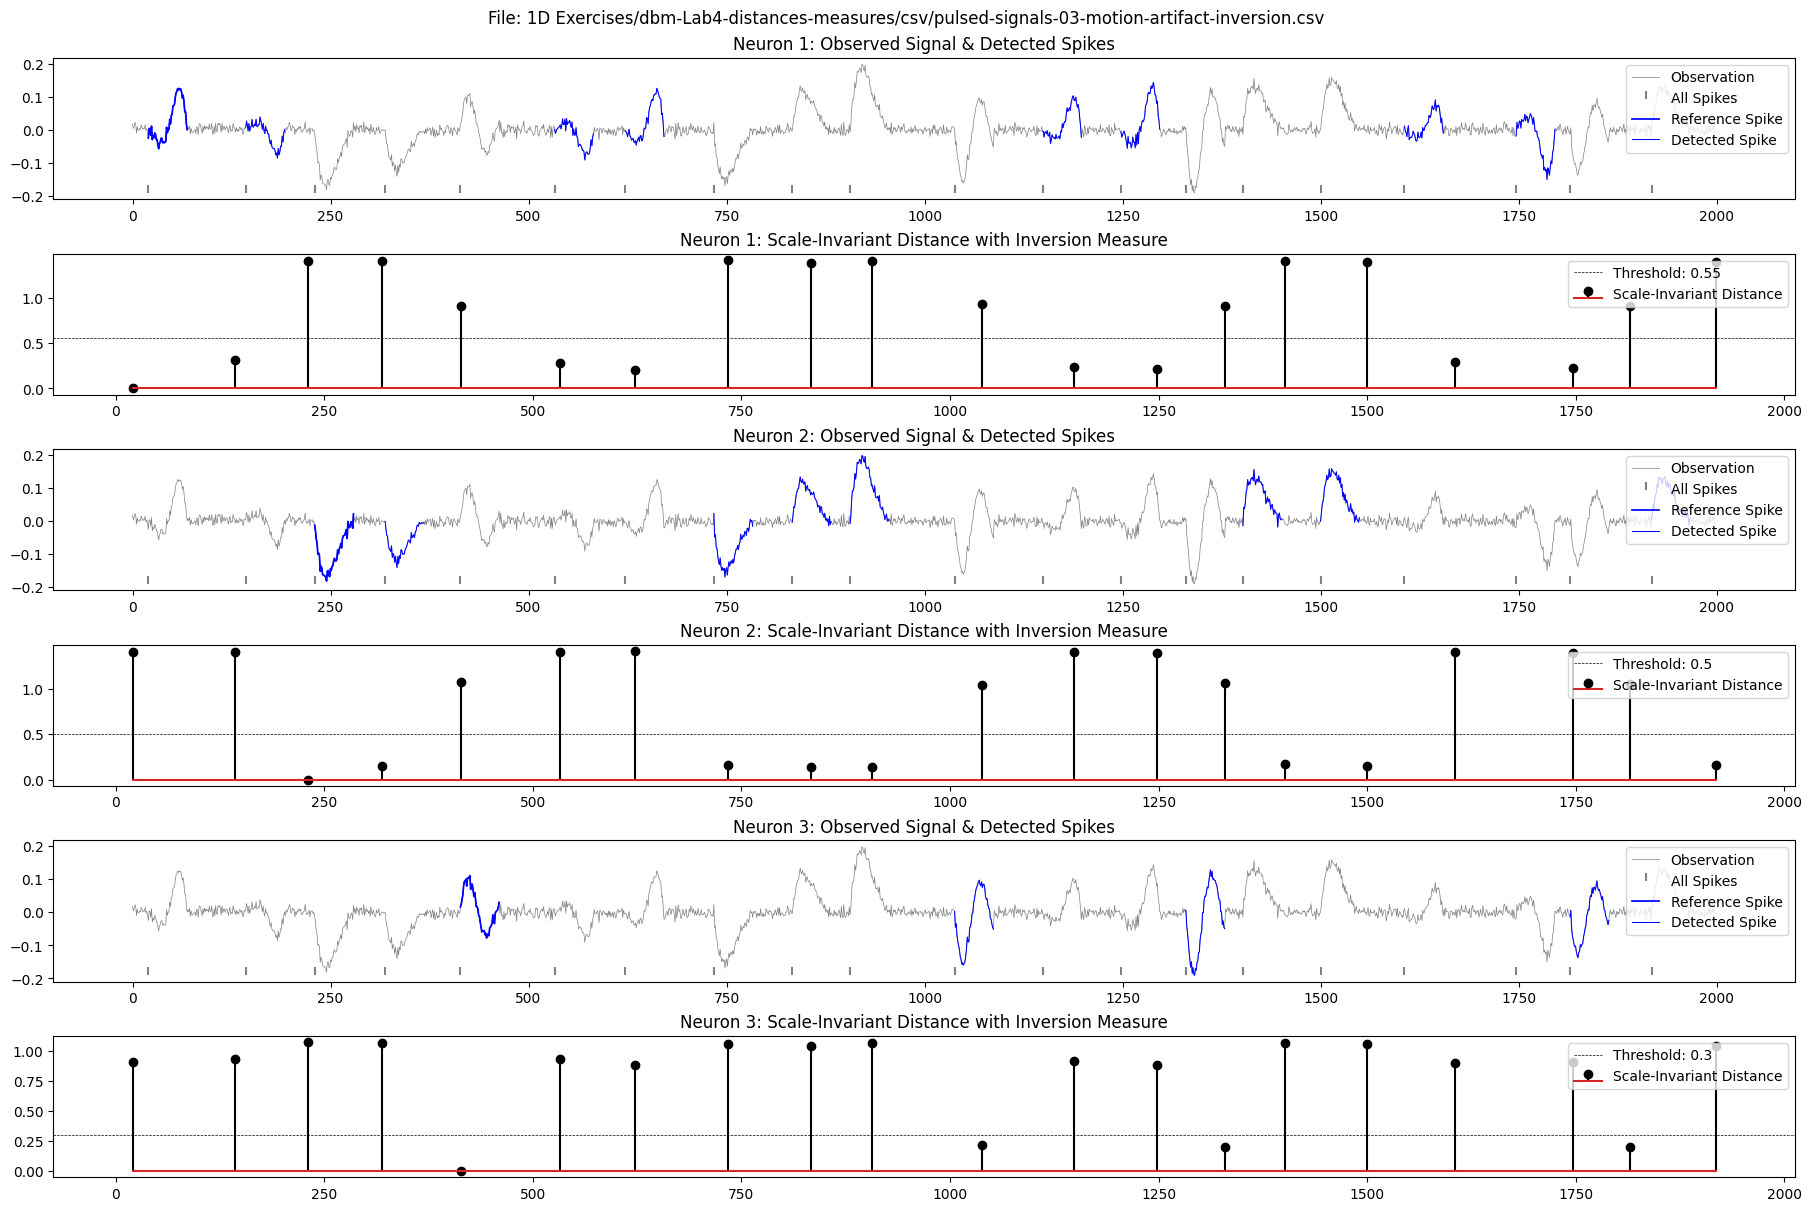

In [131]:
fig, axes = plt.subplots(len(REF_INDEX) * 2, 1, figsize=(18, 4 * len(REF_INDEX)), constrained_layout=True)
plt.suptitle(f"File: {FILENAME}")

for idx, neuron_id in enumerate(REF_INDEX.keys()):  # Loop through all neurons
    ref_idx = REF_INDEX[neuron_id]  # Get reference index for this neuron
    threshold = THRESHOLDS[neuron_id]  # Get threshold for this neuron
    
    # Compute scale-invariant distances with inversion handling
    distances_scaled = np.array([
        scale_invariant_distance_with_inversion(zs[ref_idx], zs[i]) for i in range(NOF_SPIKES)
    ])
    
    # Detect spikes for the neuron
    indices_spikes_detected = [
        k0 for k0, dist in zip(indices_spikes, distances_scaled)
        if neuron_sources[k0] == neuron_id and dist < threshold
    ]
    
    # Select reference spike for the neuron
    reference_spike = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    
    # Observed Signal & Detected Spikes
    ax_signal = axes[idx * 2]
    ax_signal.set_title(f"Neuron {neuron_id}: Observed Signal & Detected Spikes")
    ax_signal.plot(range(K), y, lw=0.5, c='gray', label='Observation')
    ax_signal.scatter(indices_spikes, np.ones_like(indices_spikes) * y.min(), marker=2, c='gray', label="All Spikes")  
    
    if reference_spike is not None:
        ax_signal.plot(range(SPIKE_WIDTH) + reference_spike, y[range(SPIKE_WIDTH) + reference_spike], lw=1.25, c='b', label='Reference Spike')  
    
    for k0 in indices_spikes_detected:  
        ax_signal.plot(range(SPIKE_WIDTH) + k0, y[range(SPIKE_WIDTH) + k0], lw=0.75, c='blue', label='Detected Spike' if k0 == indices_spikes_detected[0] else "")
    
    ax_signal.legend(loc="upper right")
    
    # Distance Measure Plot
    ax_distance = axes[idx * 2 + 1]
    ax_distance.set_title(f"Neuron {neuron_id}: Scale-Invariant Distance with Inversion Measure")
    ax_distance.stem(indices_spikes, distances_scaled, 'k', markerfmt='ko', linefmt='k-', label='Scale-Invariant Distance')
    ax_distance.axhline(y=threshold, ls='--', lw=0.5, c='k', label=f"Threshold: {threshold}")
    ax_distance.legend(loc="upper right")

plt.show()


### d) Base-Line Signal Drift
This can occur due to sensor motion. 
The base-line drift is a low-frequency artifact, often caused by movement, skin-electrode impedance changes, or slow drifts in the signal. 
Solution: 
- remove the low frequencies while keeping the high ones -> high-pass filter

In [132]:
from scipy.signal import butter, filtfilt

FILENAME = "1D Exercises/dbm-Lab4-distances-measures/csv/pulsed-signals-04-baseline-drift.csv"

#### Function for High-Pass Filter
To remove the baseline drift.

In [133]:
def high_pass_filter(signal, cutoff=0.1, fs=1.0, order=3):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, signal) # filtfilt applies the filter twice (forwards & backwards) to avoid phase shift

#### Loading Signal, Performing Slicing & Finding Reference Indices

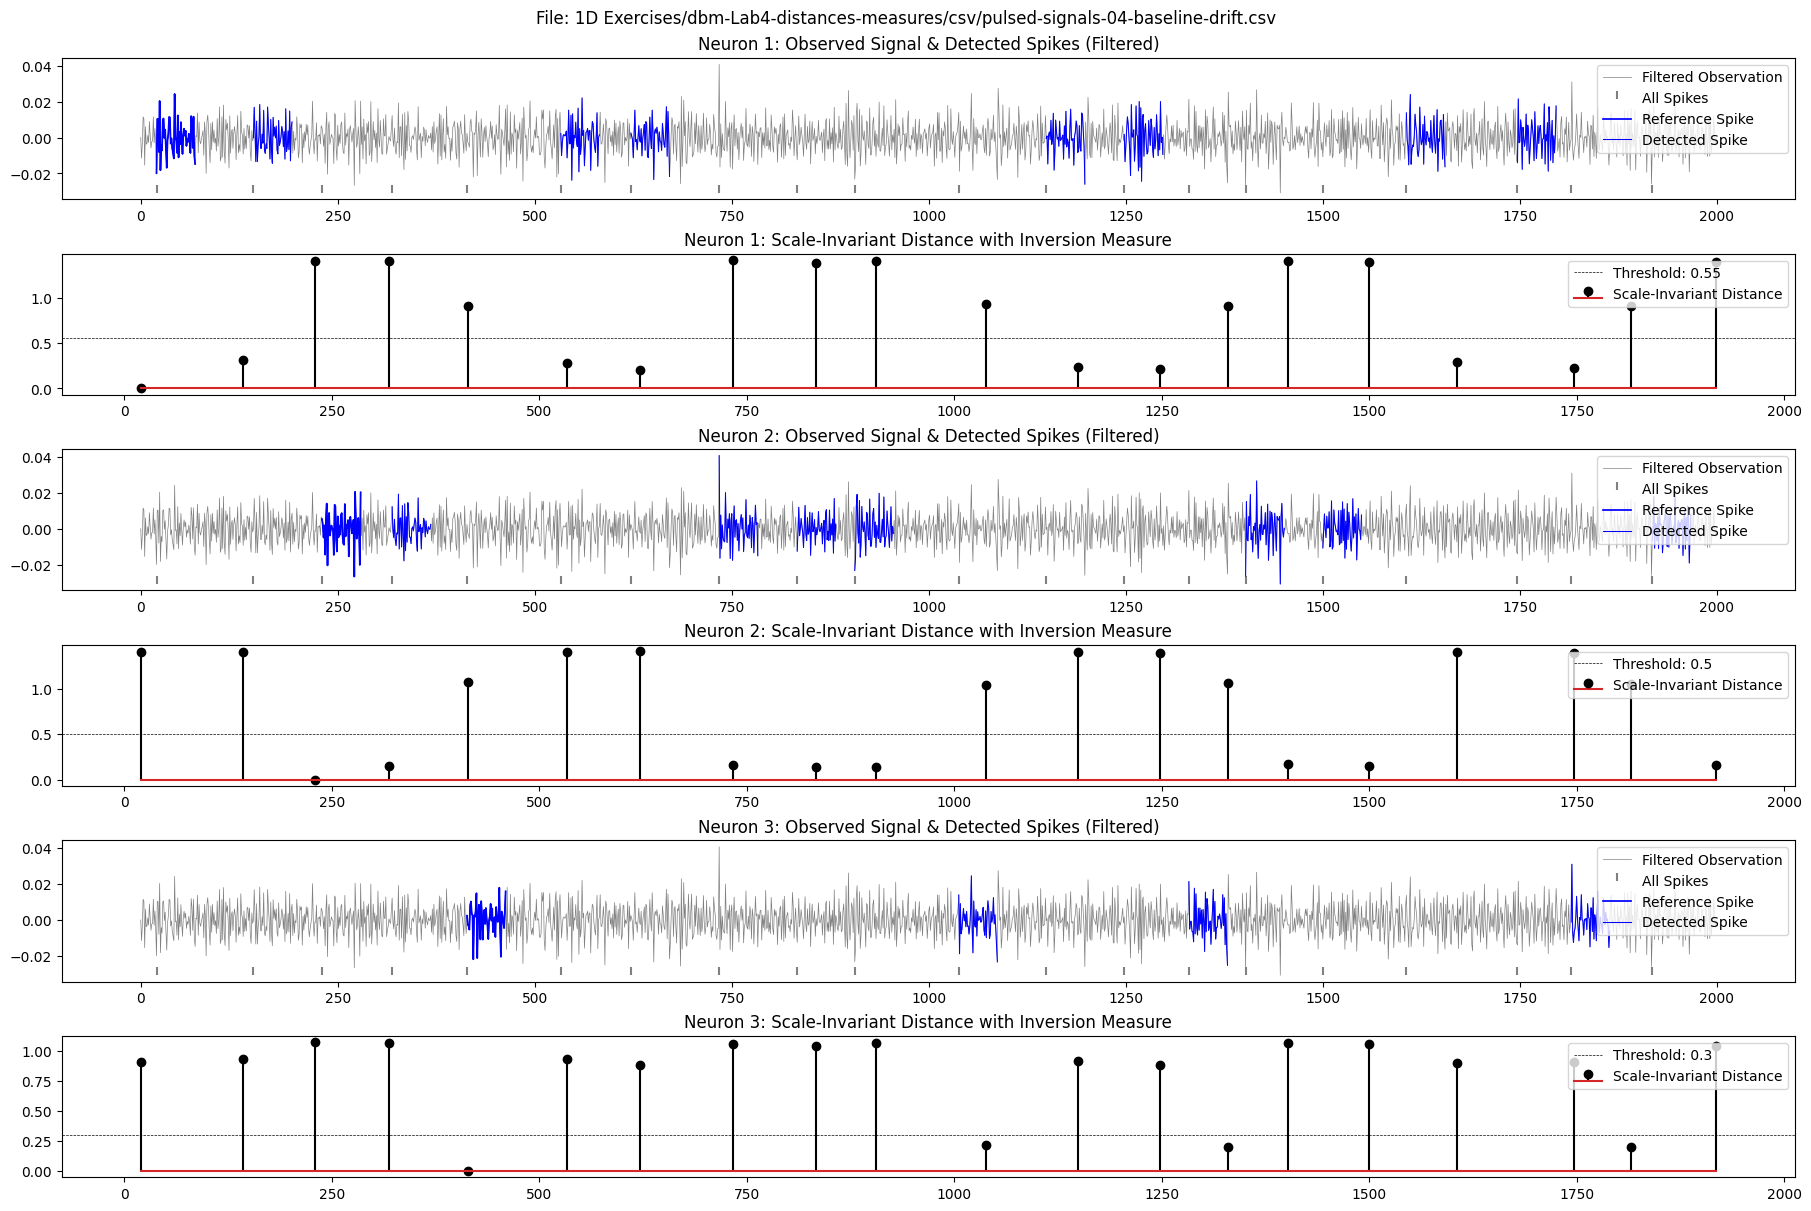

In [134]:
fig, axes = plt.subplots(len(REF_INDEX) * 2, 1, figsize=(18, 4 * len(REF_INDEX)), constrained_layout=True)
plt.suptitle(f"File: {FILENAME}")

# Preprocess the signal with high-pass filtering
y_filtered = high_pass_filter(y)

for idx, neuron_id in enumerate(REF_INDEX.keys()):  # Loop through all neurons
    ref_idx = REF_INDEX[neuron_id]  # Get reference index for this neuron
    threshold = THRESHOLDS[neuron_id]  # Get threshold for this neuron
    
    # Compute scale-invariant distances with inversion handling
    distances_scaled = np.array([
        scale_invariant_distance_with_inversion(zs[ref_idx], zs[i]) for i in range(NOF_SPIKES) # this is the function we defined earlier
    ])
    
    # Detect spikes for the neuron
    indices_spikes_detected = [
        k0 for k0, dist in zip(indices_spikes, distances_scaled)
        if neuron_sources[k0] == neuron_id and dist < threshold
    ]
    
    # Select reference spike for the neuron
    reference_spike = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    
    # Observed Signal & Detected Spikes
    ax_signal = axes[idx * 2]
    ax_signal.set_title(f"Neuron {neuron_id}: Observed Signal & Detected Spikes (Filtered)")
    ax_signal.plot(range(K), y_filtered, lw=0.5, c='gray', label='Filtered Observation')
    ax_signal.scatter(indices_spikes, np.ones_like(indices_spikes) * y_filtered.min(), marker=2, c='gray', label="All Spikes")  
    
    if reference_spike is not None:
        ax_signal.plot(range(SPIKE_WIDTH) + reference_spike, y_filtered[range(SPIKE_WIDTH) + reference_spike], lw=1.25, c='b', label='Reference Spike')  
    
    for k0 in indices_spikes_detected:  
        ax_signal.plot(range(SPIKE_WIDTH) + k0, y_filtered[range(SPIKE_WIDTH) + k0], lw=0.75, c='blue', label='Detected Spike' if k0 == indices_spikes_detected[0] else "")
    
    ax_signal.legend(loc="upper right")
    
    # Distance Measure Plot
    ax_distance = axes[idx * 2 + 1]
    ax_distance.set_title(f"Neuron {neuron_id}: Scale-Invariant Distance with Inversion Measure")
    ax_distance.stem(indices_spikes, distances_scaled, 'k', markerfmt='ko', linefmt='k-', label='Scale-Invariant Distance')
    ax_distance.axhline(y=threshold, ls='--', lw=0.5, c='k', label=f"Threshold: {threshold}")
    ax_distance.legend(loc="upper right")

plt.show()


### e) Base-Line Signal Drift & Variable Spike Amplitudes
This is the exact same code as for d) because I already used the scale-invariant distance (with inversion, just in case, even though I couldn't detect any inversed signals).
It works to successfully identify all three neurons and their occurences.

In [135]:
FILENAME = "1D Exercises/dbm-Lab4-distances-measures/csv/pulsed-signals-05-strong-distortion.csv"

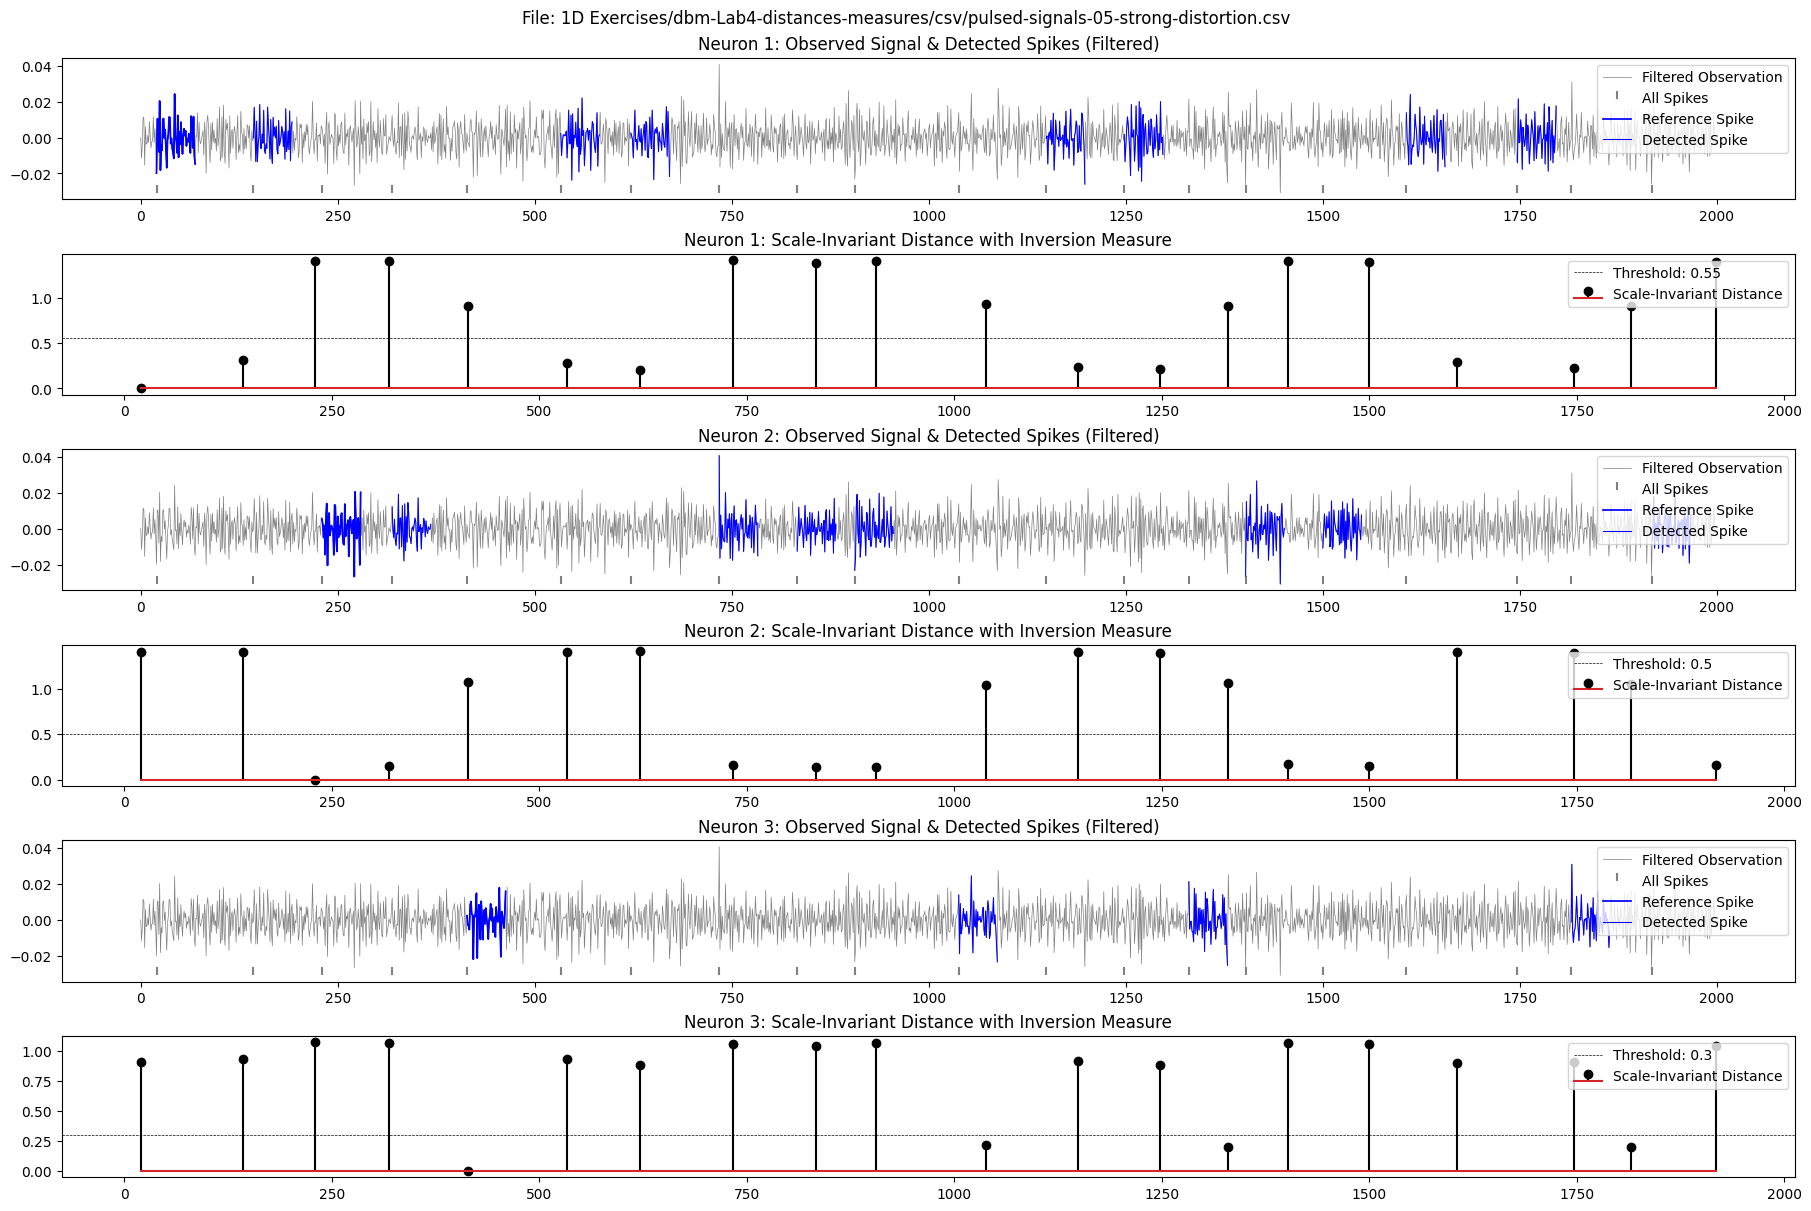

In [136]:
fig, axes = plt.subplots(len(REF_INDEX) * 2, 1, figsize=(18, 4 * len(REF_INDEX)), constrained_layout=True)
plt.suptitle(f"File: {FILENAME}")

def high_pass_filter(signal, cutoff=0.1, fs=1.0, order=3):
    """ Applies a high-pass filter to remove baseline drift. """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, signal) # filtfilt applies the filter twice (forwards & backwards) to avoid phase shift

# Preprocess the signal with high-pass filtering
y_filtered = high_pass_filter(y)

for idx, neuron_id in enumerate(REF_INDEX.keys()):  # Loop through all neurons
    ref_idx = REF_INDEX[neuron_id]  # Get reference index for this neuron
    threshold = THRESHOLDS[neuron_id]  # Get threshold for this neuron
    
    # Compute scale-invariant distances with inversion handling
    distances_scaled = np.array([
        scale_invariant_distance_with_inversion(zs[ref_idx], zs[i]) for i in range(NOF_SPIKES) # this is the function we defined earlier
    ])
    
    # Detect spikes for the neuron
    indices_spikes_detected = [
        k0 for k0, dist in zip(indices_spikes, distances_scaled)
        if neuron_sources[k0] == neuron_id and dist < threshold
    ]
    
    # Select reference spike for the neuron
    reference_spike = next((k0 for k0 in indices_spikes if neuron_sources[k0] == neuron_id), None)
    
    # Observed Signal & Detected Spikes
    ax_signal = axes[idx * 2]
    ax_signal.set_title(f"Neuron {neuron_id}: Observed Signal & Detected Spikes (Filtered)")
    ax_signal.plot(range(K), y_filtered, lw=0.5, c='gray', label='Filtered Observation')
    ax_signal.scatter(indices_spikes, np.ones_like(indices_spikes) * y_filtered.min(), marker=2, c='gray', label="All Spikes")  
    
    if reference_spike is not None:
        ax_signal.plot(range(SPIKE_WIDTH) + reference_spike, y_filtered[range(SPIKE_WIDTH) + reference_spike], lw=1.25, c='b', label='Reference Spike')  
    
    for k0 in indices_spikes_detected:  
        ax_signal.plot(range(SPIKE_WIDTH) + k0, y_filtered[range(SPIKE_WIDTH) + k0], lw=0.75, c='blue', label='Detected Spike' if k0 == indices_spikes_detected[0] else "")
    
    ax_signal.legend(loc="upper right")
    
    # Distance Measure Plot
    ax_distance = axes[idx * 2 + 1]
    ax_distance.set_title(f"Neuron {neuron_id}: Scale-Invariant Distance with Inversion Measure")
    ax_distance.stem(indices_spikes, distances_scaled, 'k', markerfmt='ko', linefmt='k-', label='Scale-Invariant Distance')
    ax_distance.axhline(y=threshold, ls='--', lw=0.5, c='k', label=f"Threshold: {threshold}")
    ax_distance.legend(loc="upper right")

plt.show()
